# Sistemas de Decisión Inteligente Basados en Aprendizaje por Refuerzo: Optimización de Inventarios y Navegación Autónoma en Almacenes

**Curso:** Inteligencia Artificial
**Docente:** Prof. Maguiña
**Universidad Nacional Mayor de San Marcos (UNMSM)**
**Escuela Profesional de Ingeniería de Software**

### Integrantes

| Apellidos y Nombres | Código de Estudiante |
|---|---|
| Lopez Salinas, Leonardo Miguel | 23200104 |
| Tarqui Soncco, Nicolás Alejandro Inti | 23200121 |
| Cueva Alcala, Axel Andree | 23200093 |
| Carrasco Flores, Ángel Giovanny | 23200086 |

---

### Resumen del proyecto

Este trabajo desarrolla e implementa dos sistemas de toma de decisiones inteligentes basados en **Aprendizaje por Refuerzo (Reinforcement Learning, RL)**, aplicados a problemas reales de baja complejidad en los sectores **comercial** y **logístico/industrial**:

1. **Gestión de Inventarios** (sector comercial): un agente decide cuánto pedir a un proveedor para maximizar ganancias minimizando costos de almacenamiento y quiebres de stock.
2. **Ruta Óptima de un Vehículo Autónomo (AGV) en Almacén** (sector logístico/industrial): un agente aprende a navegar una cuadrícula evitando obstáculos para llegar a un punto de entrega.

Ambos casos se resuelven con el algoritmo **Q-Learning tabular**, se implementan en Python con entornos personalizados (interfaz compatible con el estándar `reset()`/`step()` de Gymnasium), y se exponen mediante una **interfaz de usuario en Streamlit** que permite configurar hiperparámetros, entrenar a los agentes y visualizar su comportamiento y métricas de aprendizaje.

**Instrucciones de ejecución:** este notebook está diseñado para ejecutarse de principio a fin con *Restart & Run All*. No requiere archivos externos; todas las dependencias se instalan en la primera celda de código.


## 0. Instalación de Dependencias

Ejecutar esta celda primero. Instala las librerías necesarias para todo el notebook.

In [ ]:
# Instalación de dependencias (descomentar si se ejecuta por primera vez en un entorno nuevo)
!pip install gymnasium numpy matplotlib streamlit pandas networkx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 65.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, field
import networkx as nx

# Configuración general de gráficos
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

# Semilla global para reproducibilidad de los resultados reportados en el análisis
SEED_GLOBAL = 42
np.random.seed(SEED_GLOBAL)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 1. Marco Teórico

### 1.1 El Proceso de Decisión de Markov (MDP)

El **Aprendizaje por Refuerzo** formaliza el problema de aprender a tomar decisiones secuenciales mediante un **Proceso de Decisión de Markov (MDP)**, definido por la tupla $(S, A, P, R, \gamma)$:

- **Estado ($S$):** conjunto de todas las situaciones posibles en las que puede encontrarse el agente. En el caso de inventarios, $S$ es el nivel de stock disponible; en el caso del AGV, $S$ son las coordenadas $(x, y)$ del robot en la cuadrícula del almacén.
- **Acción ($A$):** conjunto de decisiones que el agente puede tomar en cada estado. En inventarios, $A$ es la cantidad de unidades a pedir; en el AGV, $A$ son los cuatro movimientos posibles (arriba, abajo, izquierda, derecha).
- **Probabilidad de Transición ($P$):** $P(s'|s,a)$ es la probabilidad de pasar al estado $s'$ dado que se ejecuta la acción $a$ en el estado $s$. En nuestros entornos esta probabilidad es **estocástica** en el caso de inventarios (la demanda del cliente es aleatoria, modelada con una distribución de Poisson) y **determinista** en el caso del AGV (cada movimiento tiene un resultado fijo, salvo el límite de la cuadrícula).
- **Recompensa ($R$):** $R(s,a,s')$ es la señal numérica que el entorno entrega al agente tras ejecutar una acción, indicando qué tan buena o mala fue esa decisión.
- **Factor de Descuento ($\gamma$):** $\gamma \in [0,1]$ pondera la importancia de las recompensas futuras frente a las inmediatas. Un $\gamma$ cercano a 1 hace que el agente sea "previsor" (valora el largo plazo); un $\gamma$ cercano a 0 lo hace "miope" (solo importa la recompensa inmediata).

La propiedad de Markov asume que el estado actual contiene toda la información relevante para decidir, sin necesidad de recordar el historial completo: $P(s_{t+1} | s_t, a_t) = P(s_{t+1} | s_t, a_t, s_{t-1}, a_{t-1}, \ldots)$.

### 1.2 El Bucle de Interacción Agente-Entorno

El aprendizaje por refuerzo se basa en un ciclo continuo de interacción:

1. El **Agente** observa el **Estado** actual $s_t$ del **Entorno**.
2. El Agente selecciona una **Acción** $a_t$ según su **política** $\pi(a|s)$.
3. El Entorno ejecuta la acción y devuelve una **Recompensa** $r_{t+1}$ y un nuevo **Estado** $s_{t+1}$.
4. El Agente actualiza su conocimiento (su tabla de valores, en nuestro caso) y el ciclo se repite.

El objetivo del agente es aprender una política $\pi^*$ que **maximice la recompensa acumulada esperada** a lo largo del tiempo:

$$G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k+1}$$

### 1.3 Algoritmo: Q-Learning

Este proyecto implementa **Q-Learning**, un algoritmo de RL **libre de modelo** (no necesita conocer $P$ ni $R$ de antemano) y de **aprendizaje fuera de política** (*off-policy*). Mantiene una tabla $Q(s,a)$ que estima el valor esperado de tomar la acción $a$ en el estado $s$ y luego actuar óptimamente.

La regla de actualización de Q-Learning es:

$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \Big[ r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \Big]$$

donde:
- $\alpha$ es la **tasa de aprendizaje** (qué tan fuerte se actualiza la tabla con cada nueva observación).
- $r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a')$ es el **objetivo TD** (Temporal-Difference target): la mejor estimación actual del valor futuro.
- El término entre corchetes es el **error TD**: la diferencia entre lo que se esperaba y lo que realmente se observó.

Para que el agente explore el espacio de estados en lugar de quedarse atrapado en las primeras decisiones que parecen buenas, se usa una política **$\epsilon$-greedy**: con probabilidad $\epsilon$ el agente elige una acción aleatoria (exploración), y con probabilidad $1-\epsilon$ elige la acción con mayor valor $Q$ conocido (explotación). En este proyecto $\epsilon$ decae gradualmente conforme avanza el entrenamiento, para explorar mucho al inicio y explotar lo aprendido hacia el final.

Dado que el requerimiento del proyecto es de **baja complejidad**, se optó por la **aproximación tabular** (tabla $Q$ de dimensión `n_estados x n_acciones`) en lugar de aproximaciones con redes neuronales (Deep Q-Learning), ya que ambos entornos tienen espacios de estados y acciones discretos y de tamaño manejable.

*(Nota: SARSA, la alternativa on-policy a Q-Learning, actualiza usando la acción que realmente se tomará a continuación según la política, en lugar del máximo de Q. Se documenta aquí como algoritmo de referencia, pero el algoritmo implementado en el software es Q-Learning, por ser más directo de ajustar a una política puramente greedy en la evaluación final.)*

### 1.4 Aprendizaje por Refuerzo vs. Aprendizaje Supervisado y No Supervisado

| Criterio | Aprendizaje Supervisado | Aprendizaje No Supervisado | Aprendizaje por Refuerzo |
|---|---|---|---|
| **Tipo de datos** | Etiquetados (entrada → salida conocida) | No etiquetados | Interacciones (estado, acción, recompensa) |
| **Objetivo** | Minimizar el error de predicción respecto a una etiqueta conocida | Descubrir estructura/patrones ocultos en los datos | Maximizar la recompensa acumulada a largo plazo |
| **Retroalimentación** | Inmediata y exacta (la etiqueta correcta) | No hay retroalimentación externa | Retardada y parcial (solo una señal de recompensa, no la "respuesta correcta") |
| **Naturaleza del problema** | Estático: el dataset no cambia con las predicciones | Estático | Secuencial y dinámico: cada acción afecta los estados futuros |
| **Ejemplo típico** | Clasificar correos como spam o no spam | Agrupar clientes por comportamiento de compra | Decidir cuánto pedir cada día según el stock actual |

**Justificación de RL para nuestros casos de estudio:** tanto la gestión de inventarios como la navegación de un AGV son problemas de **decisión secuencial**, donde cada decisión (pedir cierta cantidad, moverse en una dirección) afecta el estado futuro del sistema y no existe un dataset previo de "decisiones correctas" etiquetadas. No se trata de predecir una etiqueta a partir de datos históricos (lo cual descartaría el aprendizaje supervisado), ni de encontrar agrupaciones o patrones en datos sin estructura de decisión (lo cual descartaría el aprendizaje no supervisado). Se trata de **aprender una política de acción óptima por ensayo y error**, interactuando repetidamente con el entorno y recibiendo una señal de recompensa que refleja qué tan buena fue cada decisión — exactamente el escenario para el que está diseñado el Aprendizaje por Refuerzo.

### 1.5 Herramientas de Software Utilizadas

- **Python 3:** lenguaje base de implementación.
- **Gymnasium (Farama Foundation):** estándar de facto para definir entornos de RL mediante la interfaz `reset()` / `step()`. Aunque se programaron clases de entorno propias para ajustarse exactamente a cada caso de estudio, se siguió esta interfaz estándar para mantener compatibilidad y buenas prácticas de la comunidad de RL.
- **NumPy:** manejo eficiente de las tablas Q (matrices de valores estado-acción) y operaciones vectorizadas.
- **Matplotlib / Pandas:** generación de gráficos de las curvas de aprendizaje (recompensa y pasos por episodio) y manejo tabular de resultados experimentales.
- **Streamlit:** framework para construir la interfaz de usuario web, que permite modificar hiperparámetros ($\alpha$, $\gamma$, $\epsilon$), lanzar el entrenamiento y visualizar gráficamente el comportamiento aprendido por el agente.


## 2. Algoritmo de Q-Learning (Módulo Reutilizable)

Antes de definir cada caso de estudio, se implementa una clase genérica `AgenteQLearning` y una función `entrenar()` que se reutilizarán para **ambos** entornos. Esto evita duplicar código y refleja una arquitectura de software modular, tal como exige la consigna.

In [ ]:
class AgenteQLearning:
    """
    Agente de Q-Learning tabular, válido para cualquier entorno discreto
    que implemente la interfaz reset() / step() utilizada en este proyecto.

    Parámetros
    ----------
    n_states : int
        Número total de estados discretos del entorno.
    n_actions : int
        Número total de acciones discretas disponibles.
    alpha : float
        Tasa de aprendizaje (qué tanto se actualiza Q con cada nueva observación).
    gamma : float
        Factor de descuento de recompensas futuras.
    epsilon : float
        Probabilidad inicial de tomar una acción aleatoria (exploración).
    epsilon_min : float
        Valor mínimo al que puede decaer epsilon.
    epsilon_decay : float
        Factor multiplicativo de decaimiento de epsilon tras cada episodio.
    """

    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        # Tabla Q inicializada en ceros: una fila por estado, una columna por acción
        self.Q = np.zeros((n_states, n_actions))

    def elegir_accion(self, estado, modo_evaluacion=False):
        """Política epsilon-greedy. Si modo_evaluacion=True, siempre explota (epsilon=0)."""
        if (not modo_evaluacion) and (np.random.rand() < self.epsilon):
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[estado]))

    def actualizar(self, estado, accion, recompensa, siguiente_estado, done):
        """Aplica la regla de actualización de Q-Learning (ecuación de Bellman)."""
        mejor_q_siguiente = 0.0 if done else np.max(self.Q[siguiente_estado])
        objetivo_td = recompensa + self.gamma * mejor_q_siguiente
        error_td = objetivo_td - self.Q[estado, accion]
        self.Q[estado, accion] += self.alpha * error_td

    def decaer_epsilon(self):
        """Reduce epsilon gradualmente para pasar de explorar a explotar."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


def entrenar(env, agente, n_episodios=500, max_pasos_episodio=200, verbose=False):
    """
    Bucle de entrenamiento: ejecuta n_episodios completos del agente
    sobre el entorno, actualizando la tabla Q en cada paso.

    Retorna
    -------
    recompensas_por_episodio : list[float]
    pasos_por_episodio : list[int]
    """
    recompensas_por_episodio = []
    pasos_por_episodio = []

    for episodio in range(n_episodios):
        estado = env.reset()
        recompensa_total = 0.0
        pasos = 0

        for _ in range(max_pasos_episodio):
            accion = agente.elegir_accion(estado)
            siguiente_estado, recompensa, done, _info = env.step(accion)
            agente.actualizar(estado, accion, recompensa, siguiente_estado, done)

            estado = siguiente_estado
            recompensa_total += recompensa
            pasos += 1
            if done:
                break

        agente.decaer_epsilon()
        recompensas_por_episodio.append(recompensa_total)
        pasos_por_episodio.append(pasos)

        if verbose and (episodio + 1) % 100 == 0:
            print(f"Episodio {episodio + 1}/{n_episodios} | "
                  f"Recompensa: {recompensa_total:.1f} | Epsilon: {agente.epsilon:.3f}")

    return recompensas_por_episodio, pasos_por_episodio


def graficar_metricas(recompensas, pasos, titulo_extra=""):
    """Genera las dos gráficas de evaluación exigidas: recompensa y pasos por episodio."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(recompensas, color="tab:blue", alpha=0.4, label="Recompensa por episodio")
    ventana = max(1, len(recompensas) // 50)
    media_movil = pd.Series(recompensas).rolling(ventana).mean()
    axes[0].plot(media_movil, color="tab:blue", linewidth=2, label=f"Media móvil ({ventana} ep.)")
    axes[0].set_title(f"Recompensa acumulada por episodio {titulo_extra}")
    axes[0].set_xlabel("Episodio")
    axes[0].set_ylabel("Recompensa")
    axes[0].legend()

    axes[1].plot(pasos, color="tab:orange", alpha=0.4, label="Pasos por episodio")
    media_movil_pasos = pd.Series(pasos).rolling(ventana).mean()
    axes[1].plot(media_movil_pasos, color="tab:orange", linewidth=2, label=f"Media móvil ({ventana} ep.)")
    axes[1].set_title(f"Pasos por episodio {titulo_extra}")
    axes[1].set_xlabel("Episodio")
    axes[1].set_ylabel("Pasos")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

print("Clase AgenteQLearning y funciones entrenar()/graficar_metricas() definidas correctamente.")

Clase AgenteQLearning y funciones entrenar()/graficar_metricas() definidas correctamente.


## 3. Caso de Estudio 1: Gestión de Inventarios (Sector Comercial)

### 3.1 Descripción del problema

Una tienda debe decidir, día tras día, **cuántas unidades pedir** a su proveedor de un producto determinado. Pedir de más genera costos de almacenamiento innecesarios; pedir de menos provoca pérdida de ventas por desabastecimiento (faltante de stock). El objetivo es aprender una **política de reabastecimiento** que maximice la ganancia neta a lo largo del tiempo, sin necesidad de pronosticar la demanda de forma explícita.

### 3.2 Modelado como MDP

| Elemento | Definición en este caso |
|---|---|
| **Estado ($S$)** | Nivel de stock actual, entero entre $0$ y `stock_max` |
| **Acción ($A$)** | Cantidad de unidades a ordenar al proveedor, entero entre $0$ y `pedido_max` |
| **Transición ($P$)** | Estocástica: la demanda diaria del cliente se modela con una distribución de Poisson de media `demanda_media` |
| **Recompensa ($R$)** | Ingreso por ventas, menos costo del pedido, menos costo de almacenamiento del stock remanente, menos penalización por unidades de demanda no satisfecha (faltante) |
| **Factor de descuento ($\gamma$)** | Configurable en la interfaz; valora la rentabilidad sostenida en el tiempo, no solo la ganancia del día actual |

### 3.3 Implementación del entorno

Se define la clase `InventarioEnv`, que sigue la interfaz `reset()` / `step()` utilizada en este proyecto (compatible con el estilo de Gymnasium).

In [ ]:
class InventarioEnv:
    """
    Entorno de gestión de inventarios (sector comercial).

    Estado: nivel de stock actual, entero en [0, stock_max].
    Acción : cantidad de unidades a ordenar, entero en [0, pedido_max].

    En cada paso (un "día" de operación):
      1. Se recibe el pedido (el stock sube, limitado por stock_max).
      2. Ocurre una demanda aleatoria de clientes (Poisson).
      3. Se venden tantas unidades como permita el stock disponible.
      4. Se cobra costo de almacenamiento por el stock remanente
         y penalización por cada unidad de demanda no satisfecha.
    """

    def __init__(self, stock_max=20, pedido_max=10, demanda_media=5,
                 costo_almacen=1, costo_faltante=5, precio_venta=10, costo_unitario=4):
        self.stock_max = stock_max
        self.pedido_max = pedido_max
        self.demanda_media = demanda_media
        self.costo_almacen = costo_almacen
        self.costo_faltante = costo_faltante
        self.precio_venta = precio_venta
        self.costo_unitario = costo_unitario

        # Tamaños de espacio de estados/acciones, requeridos por el agente Q-Learning
        self.n_states = stock_max + 1
        self.n_actions = pedido_max + 1

        self.stock = 0

    def reset(self):
        """Reinicia el entorno a un stock inicial aleatorio bajo, como al abrir el negocio."""
        self.stock = np.random.randint(0, self.stock_max // 2 + 1)
        return self.stock

    def step(self, accion):
        """Ejecuta un día de operación dado el pedido (acción) elegido por el agente."""
        pedido = accion
        stock_tras_pedido = min(self.stock + pedido, self.stock_max)

        demanda = np.random.poisson(self.demanda_media)
        ventas = min(demanda, stock_tras_pedido)
        faltante = max(demanda - stock_tras_pedido, 0)
        nuevo_stock = stock_tras_pedido - ventas

        ingreso = ventas * self.precio_venta
        costo_pedido = pedido * self.costo_unitario
        costo_almacenaje = nuevo_stock * self.costo_almacen
        penalizacion_faltante = faltante * self.costo_faltante

        recompensa = ingreso - costo_pedido - costo_almacenaje - penalizacion_faltante

        self.stock = nuevo_stock
        done = False  # Es un proceso continuo; el episodio termina por límite de pasos
        info = {"demanda": demanda, "ventas": ventas, "faltante": faltante}

        return self.stock, recompensa, done, info


# Prueba rápida de funcionamiento del entorno
env_test = InventarioEnv()
s = env_test.reset()
print(f"Estado inicial (stock): {s}")
for i in range(3):
    a = np.random.randint(env_test.n_actions)
    s, r, done, info = env_test.step(a)
    print(f"Día {i+1}: pedido={a} -> stock={s}, recompensa={r:.1f}, info={info}")


Estado inicial (stock): 6
Día 1: pedido=3 -> stock=4, recompensa=34.0, info={'demanda': 5, 'ventas': 5, 'faltante': 0}
Día 2: pedido=7 -> stock=8, recompensa=-6.0, info={'demanda': 3, 'ventas': 3, 'faltante': 0}
Día 3: pedido=7 -> stock=12, recompensa=-10.0, info={'demanda': 3, 'ventas': 3, 'faltante': 0}


### 3.4 Entrenamiento del agente con Q-Learning

In [ ]:
np.random.seed(SEED_GLOBAL)

env_inventario = InventarioEnv(stock_max=20, pedido_max=10, demanda_media=5)
agente_inventario = AgenteQLearning(
    n_states=env_inventario.n_states,
    n_actions=env_inventario.n_actions,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
)

recompensas_inv, pasos_inv = entrenar(
    env_inventario, agente_inventario,
    n_episodios=500, max_pasos_episodio=30, verbose=True
)


Episodio 100/500 | Recompensa: 589.0 | Epsilon: 0.606
Episodio 200/500 | Recompensa: 574.0 | Epsilon: 0.367
Episodio 300/500 | Recompensa: 741.0 | Epsilon: 0.222
Episodio 400/500 | Recompensa: 689.0 | Epsilon: 0.135
Episodio 500/500 | Recompensa: 730.0 | Epsilon: 0.082


### 3.5 Métricas de evaluación: Caso 1

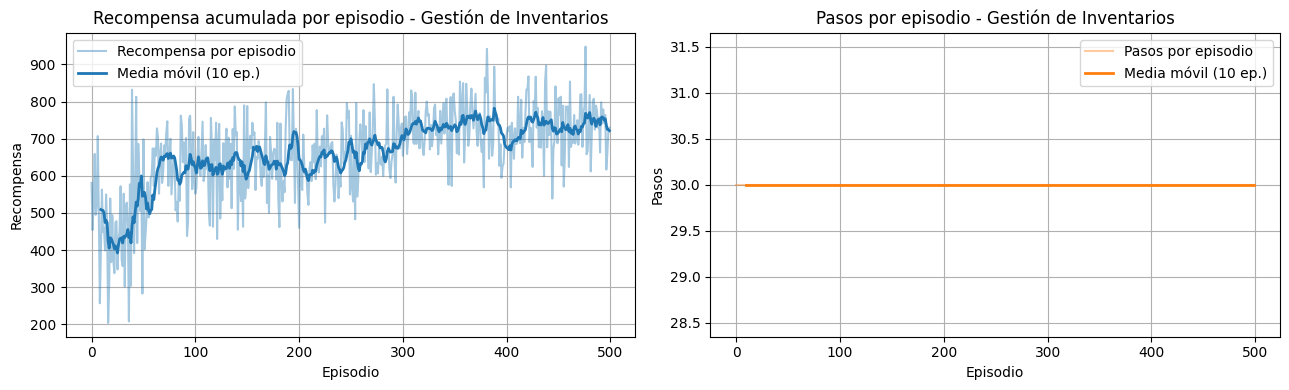

Recompensa promedio (primeros 50 episodios): 476.58
Recompensa promedio (últimos 50 episodios):  737.36


In [ ]:
graficar_metricas(recompensas_inv, pasos_inv, titulo_extra="- Gestión de Inventarios")

print(f"Recompensa promedio (primeros 50 episodios): {np.mean(recompensas_inv[:50]):.2f}")
print(f"Recompensa promedio (últimos 50 episodios):  {np.mean(recompensas_inv[-50:]):.2f}")


**Interpretación esperada:** la curva de recompensa acumulada por episodio debe mostrar una tendencia **ascendente**: al inicio el agente pide cantidades aleatorias (alta exploración) y a veces se queda sin stock o sobre-almacena, generando recompensas bajas o negativas; conforme la tabla $Q$ se actualiza, el agente aprende cuántas unidades pedir según el nivel de stock para maximizar la ganancia neta, estabilizándose en una política casi óptima.

### 3.6 Política aprendida

Se puede inspeccionar la política final del agente: para cada nivel de stock, ¿cuántas unidades decide pedir?

In [ ]:
politica_inventario = np.argmax(agente_inventario.Q, axis=1)
df_politica_inv = pd.DataFrame({
    "Stock actual": np.arange(env_inventario.n_states),
    "Pedido óptimo aprendido": politica_inventario
})
df_politica_inv.T


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
Stock actual,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
Pedido óptimo aprendido,7,6,7,5,3,3,0,0,1,5,...,1,2,0,0,3,2,1,2,6,0


## 4. Caso de Estudio 2: Ruta Óptima de un Vehículo Autónomo en Almacén (Sector Logístico/Industrial)

### 4.1 Descripción del problema

Un robot montacargas autónomo (AGV, *Automated Guided Vehicle*) debe trasladar un palé desde un punto de origen **A** hasta un punto de entrega **B** dentro de un almacén representado como una **cuadrícula (Gridworld)**, evitando obstáculos como estanterías o zonas restringidas, y haciéndolo en la menor cantidad de pasos posible.

### 4.2 Modelado como MDP

| Elemento | Definición en este caso |
|---|---|
| **Estado ($S$)** | Coordenadas $(x, y)$ del AGV dentro de la cuadrícula del almacén |
| **Acción ($A$)** | Uno de 4 movimientos: arriba, abajo, izquierda, derecha |
| **Transición ($P$)** | Determinista: cada movimiento produce un resultado fijo (salvo que choque con un obstáculo o el borde del almacén, en cuyo caso no avanza) |
| **Recompensa ($R$)** | $+100$ al llegar a la meta; $-10$ por chocar con un obstáculo; $-1$ por cada paso dado (para incentivar la ruta más corta) |
| **Factor de descuento ($\gamma$)** | Configurable; valora llegar a la meta cuanto antes |

### 4.3 Implementación del entorno

In [ ]:
class AlmacenGridEnv:
    """
    Entorno de almacén tipo cuadrícula (Gridworld) para un AGV.

    Estado : posición (x, y) codificada como un único entero (x * columnas + y).
    Acción : 0 = arriba, 1 = abajo, 2 = izquierda, 3 = derecha.
    """

    def __init__(self, filas=5, columnas=5, inicio=(0, 0), meta=(4, 4), obstaculos=None,
                 recompensa_meta=100, penalizacion_obstaculo=-10, costo_paso=-1, max_pasos=100):
        self.filas = filas
        self.columnas = columnas
        self.inicio = inicio
        self.meta = meta
        self.obstaculos = obstaculos if obstaculos is not None else [(1, 1), (2, 1), (3, 3), (1, 3)]
        self.recompensa_meta = recompensa_meta
        self.penalizacion_obstaculo = penalizacion_obstaculo
        self.costo_paso = costo_paso
        self.max_pasos = max_pasos

        self.n_states = filas * columnas
        self.n_actions = 4

        self.pos = inicio
        self.pasos_actuales = 0

    def _coord_a_estado(self, coord):
        x, y = coord
        return x * self.columnas + y

    def reset(self):
        self.pos = self.inicio
        self.pasos_actuales = 0
        return self._coord_a_estado(self.pos)

    def step(self, accion):
        self.pasos_actuales += 1
        x, y = self.pos

        if accion == 0:      # arriba
            x = max(x - 1, 0)
        elif accion == 1:    # abajo
            x = min(x + 1, self.filas - 1)
        elif accion == 2:    # izquierda
            y = max(y - 1, 0)
        elif accion == 3:    # derecha
            y = min(y + 1, self.columnas - 1)

        nueva_pos = (x, y)
        done = False

        if nueva_pos in self.obstaculos:
            recompensa = self.penalizacion_obstaculo
            nueva_pos = self.pos       # el AGV choca y permanece en su posición anterior
        elif nueva_pos == self.meta:
            recompensa = self.recompensa_meta
            done = True
        else:
            recompensa = self.costo_paso

        self.pos = nueva_pos
        if self.pasos_actuales >= self.max_pasos:
            done = True

        return self._coord_a_estado(self.pos), recompensa, done, {"pos": self.pos}


# Prueba rápida de funcionamiento del entorno
env_test2 = AlmacenGridEnv()
s = env_test2.reset()
print(f"Estado inicial: {s} (posición {env_test2.pos})")
for i in range(3):
    a = np.random.randint(env_test2.n_actions)
    s, r, done, info = env_test2.step(a)
    print(f"Paso {i+1}: acción={a} -> estado={s}, posición={info['pos']}, recompensa={r}, done={done}")


Estado inicial: 0 (posición (0, 0))
Paso 1: acción=3 -> estado=1, posición=(0, 1), recompensa=-1, done=False
Paso 2: acción=0 -> estado=1, posición=(0, 1), recompensa=-1, done=False
Paso 3: acción=0 -> estado=1, posición=(0, 1), recompensa=-1, done=False


### 4.4 Entrenamiento del agente con Q-Learning

In [ ]:
np.random.seed(SEED_GLOBAL)

env_almacen = AlmacenGridEnv(filas=5, columnas=5, inicio=(0, 0), meta=(4, 4),
                              obstaculos=[(1, 1), (2, 1), (3, 3), (1, 3)])

agente_almacen = AgenteQLearning(
    n_states=env_almacen.n_states,
    n_actions=env_almacen.n_actions,
    alpha=0.1,
    gamma=0.95,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.99,
)

recompensas_agv, pasos_agv = entrenar(
    env_almacen, agente_almacen,
    n_episodios=500, max_pasos_episodio=100, verbose=True
)


Episodio 100/500 | Recompensa: 89.0 | Epsilon: 0.366
Episodio 200/500 | Recompensa: 93.0 | Epsilon: 0.134
Episodio 300/500 | Recompensa: 92.0 | Epsilon: 0.049
Episodio 400/500 | Recompensa: 93.0 | Epsilon: 0.018
Episodio 500/500 | Recompensa: 93.0 | Epsilon: 0.010


### 4.5 Métricas de evaluación: Caso 2

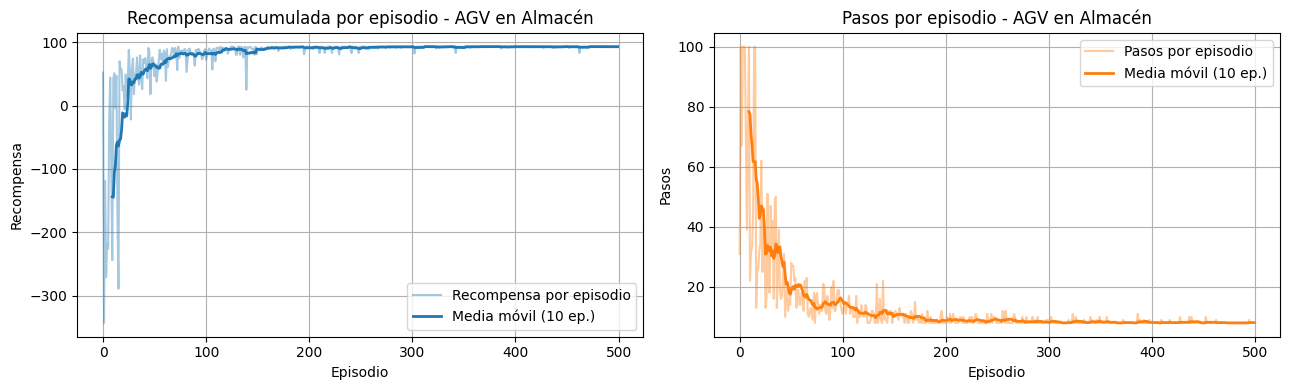

Recompensa promedio (primeros 50 episodios): -0.52
Recompensa promedio (últimos 50 episodios):  92.74
Pasos promedio (primeros 50 episodios): 40.76
Pasos promedio (últimos 50 episodios):  8.08


In [ ]:
graficar_metricas(recompensas_agv, pasos_agv, titulo_extra="- AGV en Almacén")

print(f"Recompensa promedio (primeros 50 episodios): {np.mean(recompensas_agv[:50]):.2f}")
print(f"Recompensa promedio (últimos 50 episodios):  {np.mean(recompensas_agv[-50:]):.2f}")
print(f"Pasos promedio (primeros 50 episodios): {np.mean(pasos_agv[:50]):.2f}")
print(f"Pasos promedio (últimos 50 episodios):  {np.mean(pasos_agv[-50:]):.2f}")


**Interpretación esperada:** la recompensa por episodio debe **subir** y los pasos por episodio deben **bajar** a medida que el AGV aprende a evitar obstáculos y a tomar la ruta más corta hacia la meta.

### 4.6 Visualización de la ruta aprendida

Se construye una representación visual simple (con `matplotlib`) de la cuadrícula del almacén y la ruta que sigue el agente una vez entrenado, usando su política completamente *greedy* (sin exploración).

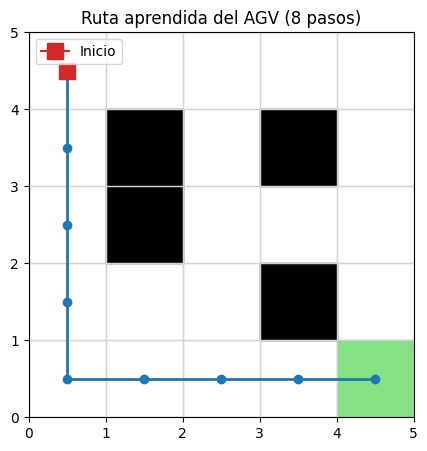

Secuencia de posiciones recorridas: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4)]


In [ ]:
def simular_politica_greedy(env, agente, max_pasos=50):
    """Ejecuta al agente con su política aprendida (sin exploración) y registra la ruta."""
    estado = env.reset()
    ruta = [env.pos]
    for _ in range(max_pasos):
        accion = agente.elegir_accion(estado, modo_evaluacion=True)
        estado, _r, done, info = env.step(accion)
        ruta.append(info["pos"])
        if done:
            break
    return ruta


def graficar_ruta_almacen(env, ruta):
    fig, ax = plt.subplots(figsize=(5, 5))

    # Dibujar cuadrícula
    for i in range(env.filas + 1):
        ax.axhline(i, color="lightgray", linewidth=1)
    for j in range(env.columnas + 1):
        ax.axvline(j, color="lightgray", linewidth=1)

    # Obstáculos
    for (ox, oy) in env.obstaculos:
        ax.add_patch(plt.Rectangle((oy, env.filas - ox - 1), 1, 1, color="black"))

    # Meta
    mx, my = env.meta
    ax.add_patch(plt.Rectangle((my, env.filas - mx - 1), 1, 1, color="limegreen", alpha=0.6))

    # Ruta del agente
    ruta_x = [p[1] + 0.5 for p in ruta]
    ruta_y = [env.filas - p[0] - 1 + 0.5 for p in ruta]
    ax.plot(ruta_x, ruta_y, marker="o", color="tab:blue", linewidth=2, markersize=6)
    ax.plot(ruta_x[0], ruta_y[0], marker="s", color="tab:red", markersize=12, label="Inicio")

    ax.set_xlim(0, env.columnas)
    ax.set_ylim(0, env.filas)
    ax.set_aspect("equal")
    ax.set_title(f"Ruta aprendida del AGV ({len(ruta) - 1} pasos)")
    ax.legend(loc="upper left")
    plt.show()


ruta_aprendida = simular_politica_greedy(env_almacen, agente_almacen)
graficar_ruta_almacen(env_almacen, ruta_aprendida)
print("Secuencia de posiciones recorridas:", ruta_aprendida)


## 5. Caso de Estudio 3: Ruteo Óptimo de un Delivery con Congestión Variable (Sector Logístico/Comercial)

### 5.1 Descripción del problema

Un repartidor debe trasladar un pedido desde un punto de origen hasta un punto de entrega dentro de una ciudad representada como un **grafo vial** (nodos = intersecciones o puntos de interés, aristas = tramos de calle). A diferencia del Caso de Estudio 2, aquí el entorno **no es una cuadrícula uniforme**: cada tramo tiene una **distancia propia** y un **nivel de congestión propio** (una avenida principal puede ser la ruta más corta en distancia, pero estar saturada de tráfico; una calle secundaria puede ser más larga pero mucho más fluida). El objetivo del agente es aprender la ruta que minimiza el **tiempo real de viaje**, no necesariamente la distancia más corta.

### 5.2 Modelado como MDP

| Elemento | Definición en este caso |
|---|---|
| **Estado ($S$)** | Nodo (intersección) en el que se encuentra actualmente el repartidor |
| **Acción ($A$)** | Índice que selecciona uno de los vecinos del nodo actual, según una lista de adyacencia fija por nodo (acción "inválida" si el nodo tiene menos vecinos que ese índice) |
| **Transición ($P$)** | Determinista en la topología (moverse a un vecino), pero **estocástica en el costo**: el tiempo de cada tramo varía por ruido aleatorio que simula variabilidad real del tráfico |
| **Recompensa ($R$)** | $-$tiempo de viaje del tramo (distancia × congestión × ruido); bono grande al llegar al destino; penalización fija por intentar un movimiento inválido |
| **Factor de descuento ($\gamma$)** | Valora llegar cuanto antes, igual que en el Caso 2 |

Este caso reutiliza exactamente la misma clase `AgenteQLearning` y la función `entrenar()` definidas en la Sección 2, demostrando la modularidad de la arquitectura del proyecto: basta con definir un nuevo entorno con la interfaz `reset()`/`step()` para aplicar RL a un dominio completamente distinto (un grafo en vez de una cuadrícula).

### 5.3 Implementación del entorno

In [ ]:
class DeliveryEnv:
    """
    Entorno de ruteo de delivery sobre un grafo vial con congestión variable por tramo.

    Estado: nodo actual (intersección) donde se encuentra el repartidor.
    Acción: índice 0..grado_max-1 que selecciona un vecino del nodo actual,
            según una lista de adyacencia fija y ordenada por nodo. Si el nodo
            actual tiene menos vecinos que ese índice, la acción es inválida
            (el repartidor se queda en su lugar y recibe una penalización,
            de forma análoga a chocar contra un obstáculo en el Caso 2).
    """

    def __init__(self, grado_max=4, origen=0, destino=7,
                 costo_paso_invalido=-15, bono_entrega=120, max_pasos=25):
        # Coordenadas de cada nodo, usadas únicamente para la visualización del grafo
        self.coords = {
            0: (0, 0), 1: (2, 0.5), 2: (1, 2.5), 3: (4, -0.5),
            4: (3.2, 2.3), 5: (5.2, 1.2), 6: (2, 4.5), 7: (6, 3.5),
            8: (4.2, 4.5), 9: (0, 2.8),
        }
        # (nodo_a, nodo_b, distancia_km, nivel_congestion)
        # nivel_congestion es un multiplicador del tiempo de viaje:
        # 1.0 = tránsito fluido; valores > 2.0 = avenida muy congestionada
        aristas_base = [
            (0, 1, 1.8, 2.6),   # avenida principal: ruta corta en distancia, pero saturada
            (0, 9, 3.0, 1.0),   # calle secundaria, fluida
            (1, 3, 1.8, 2.4),   # avenida principal
            (1, 2, 2.0, 1.1),
            (2, 4, 2.0, 1.0),
            (2, 9, 2.4, 1.0),
            (3, 5, 1.8, 2.2),   # avenida principal
            (4, 5, 2.1, 1.9),   # tramo con tráfico medio-alto
            (4, 8, 2.8, 1.0),
            (4, 6, 2.5, 1.0),
            (5, 7, 1.8, 2.5),   # avenida principal, acceso muy congestionado al destino
            (6, 8, 1.9, 1.0),
            (6, 9, 2.2, 1.0),
            (8, 7, 1.7, 1.0),   # calle alterna fluida hacia el destino
        ]

        self.n_nodos = len(self.coords)
        self.grado_max = grado_max
        self.origen = origen
        self.destino = destino
        self.costo_paso_invalido = costo_paso_invalido
        self.bono_entrega = bono_entrega
        self.max_pasos = max_pasos

        # Lista de adyacencia (grafo no dirigido) + distancia y congestión de cada arista
        self.adyacencia = {n: [] for n in range(self.n_nodos)}
        self.distancia_base = {}
        self.congestion_base = {}
        for a, b, d, c in aristas_base:
            self.adyacencia[a].append(b)
            self.adyacencia[b].append(a)
            self.distancia_base[(a, b)] = d
            self.distancia_base[(b, a)] = d
            self.congestion_base[(a, b)] = c
            self.congestion_base[(b, a)] = c
        for n in self.adyacencia:
            self.adyacencia[n] = sorted(self.adyacencia[n])

        self.n_states = self.n_nodos
        self.n_actions = self.grado_max

        self.nodo_actual = origen
        self.pasos_actuales = 0

    def reset(self):
        self.nodo_actual = self.origen
        self.pasos_actuales = 0
        return self.nodo_actual

    def step(self, accion):
        self.pasos_actuales += 1
        vecinos = self.adyacencia[self.nodo_actual]
        info = {"nodo_previo": self.nodo_actual, "valido": True, "distancia": 0.0, "tiempo_viaje": 0.0}

        if accion >= len(vecinos):
            recompensa = self.costo_paso_invalido
            info["valido"] = False
            nuevo_nodo = self.nodo_actual
        else:
            nuevo_nodo = vecinos[accion]
            distancia = self.distancia_base[(self.nodo_actual, nuevo_nodo)]
            congestion = self.congestion_base[(self.nodo_actual, nuevo_nodo)]
            ruido = max(0.7, np.random.normal(1.0, 0.10))  # variabilidad real del tráfico
            tiempo_viaje = distancia * congestion * ruido
            info["distancia"] = distancia
            info["tiempo_viaje"] = tiempo_viaje

            if nuevo_nodo == self.destino:
                recompensa = self.bono_entrega - tiempo_viaje
            else:
                recompensa = -tiempo_viaje

        self.nodo_actual = nuevo_nodo
        done = (self.nodo_actual == self.destino) or (self.pasos_actuales >= self.max_pasos)
        info["pos"] = self.nodo_actual
        return self.nodo_actual, recompensa, done, info


# Prueba rápida de funcionamiento del entorno
env_test3 = DeliveryEnv()
s = env_test3.reset()
print(f"Estado inicial (nodo): {s}")
for i in range(3):
    a = np.random.randint(env_test3.n_actions)
    s, r, done, info = env_test3.step(a)
    print(f"Paso {i+1}: acción={a} -> nodo={s}, recompensa={r:.2f}, info={info}")

Estado inicial (nodo): 0
Paso 1: acción=2 -> nodo=0, recompensa=-15.00, info={'nodo_previo': 0, 'valido': False, 'distancia': 0.0, 'tiempo_viaje': 0.0, 'pos': 0}
Paso 2: acción=3 -> nodo=0, recompensa=-15.00, info={'nodo_previo': 0, 'valido': False, 'distancia': 0.0, 'tiempo_viaje': 0.0, 'pos': 0}
Paso 3: acción=0 -> nodo=1, recompensa=-4.93, info={'nodo_previo': 0, 'valido': True, 'distancia': 1.8, 'tiempo_viaje': 4.934471799105248, 'pos': 1}


### 5.4 Entrenamiento del agente con Q-Learning

In [ ]:
np.random.seed(SEED_GLOBAL)

env_delivery = DeliveryEnv(origen=0, destino=7)
agente_delivery = AgenteQLearning(
    n_states=env_delivery.n_states,
    n_actions=env_delivery.n_actions,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
)

recompensas_del, pasos_del = entrenar(
    env_delivery, agente_delivery,
    n_episodios=600, max_pasos_episodio=25, verbose=True
)

Episodio 100/600 | Recompensa: 45.3 | Epsilon: 0.606
Episodio 200/600 | Recompensa: 103.6 | Epsilon: 0.367
Episodio 300/600 | Recompensa: 90.2 | Epsilon: 0.222
Episodio 400/600 | Recompensa: 111.7 | Epsilon: 0.135
Episodio 500/600 | Recompensa: 110.9 | Epsilon: 0.082
Episodio 600/600 | Recompensa: 111.6 | Epsilon: 0.049


### 5.5 Métricas de evaluación: Caso 3

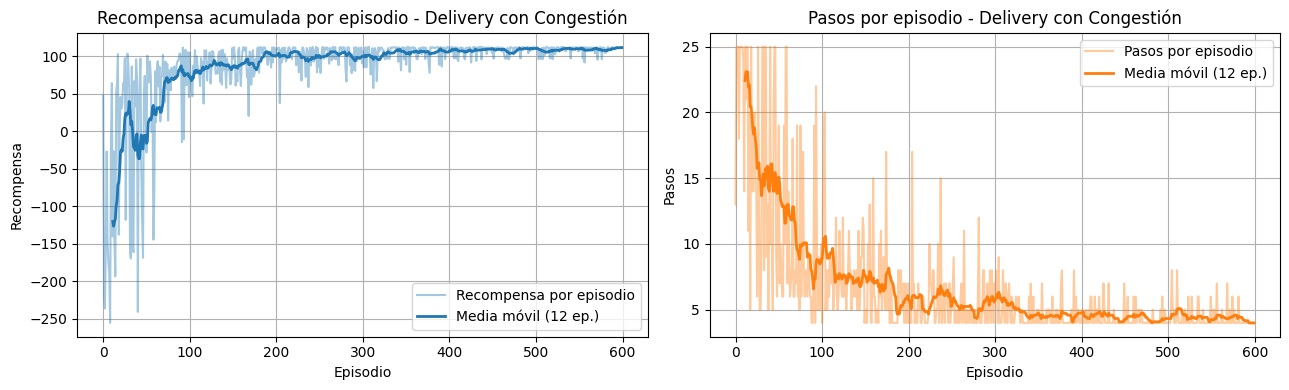

Recompensa promedio (primeros 30 episodios): -43.87
Recompensa promedio (últimos 30 episodios):  109.43


In [ ]:
graficar_metricas(recompensas_del, pasos_del, titulo_extra="- Delivery con Congestión")

print(f"Recompensa promedio (primeros 30 episodios): {np.mean(recompensas_del[:30]):.2f}")
print(f"Recompensa promedio (últimos 30 episodios):  {np.mean(recompensas_del[-30:]):.2f}")

### 5.6 Visualización de la ruta aprendida y comparación contra la ruta más corta

Para demostrar el valor agregado del RL frente a un enfoque clásico, se calcula también la **ruta más corta por distancia** usando el algoritmo de Dijkstra (vía `networkx`), y se compara su tiempo real de viaje (afectado por la congestión) contra el de la ruta aprendida por el agente.

In [ ]:
def simular_ruta_delivery(env, agente, max_pasos=20):
    """Ejecuta al agente con su política aprendida (sin exploración) y registra la ruta."""
    estado = env.reset()
    ruta = [env.nodo_actual]
    dist_total, tiempo_total = 0.0, 0.0
    for _ in range(max_pasos):
        accion = agente.elegir_accion(estado, modo_evaluacion=True)
        estado, r, done, info = env.step(accion)
        if info["valido"]:
            dist_total += info["distancia"]
            tiempo_total += info["tiempo_viaje"]
        ruta.append(info["pos"])
        if done:
            break
    return ruta, dist_total, tiempo_total


def construir_grafo_nx(env):
    """Construye un grafo de networkx a partir del entorno, para Dijkstra y visualización."""
    G = nx.Graph()
    vistas = set()
    for (a, b), d in env.distancia_base.items():
        if (b, a) not in vistas:
            G.add_edge(a, b, weight=d, congestion=env.congestion_base[(a, b)])
            vistas.add((a, b))
    return G


def costo_esperado(env, ruta):
    """Distancia total y tiempo esperado (sin ruido aleatorio) de recorrer una ruta fija."""
    d_total, t_total = 0.0, 0.0
    for a, b in zip(ruta[:-1], ruta[1:]):
        d = env.distancia_base[(a, b)]
        c = env.congestion_base[(a, b)]
        d_total += d
        t_total += d * c
    return d_total, t_total


# Ruta aprendida por el agente (política greedy)
ruta_rl, dist_rl, tiempo_rl_ruido = simular_ruta_delivery(env_delivery, agente_delivery)

# Ruta más corta en distancia pura (ignora congestión), calculada con Dijkstra
G_nx = construir_grafo_nx(env_delivery)
ruta_corta = nx.shortest_path(G_nx, source=env_delivery.origen, target=env_delivery.destino, weight="weight")

d_corta, t_corta = costo_esperado(env_delivery, ruta_corta)
d_rl, t_rl = costo_esperado(env_delivery, ruta_rl)

print(f"Ruta más corta (Dijkstra, solo distancia): {ruta_corta}")
print(f"  -> distancia = {d_corta:.1f} km | tiempo esperado con congestión = {t_corta:.1f}")
print(f"Ruta aprendida por el agente (RL, evita congestión): {ruta_rl}")
print(f"  -> distancia = {d_rl:.1f} km | tiempo esperado con congestión = {t_rl:.1f}")
print(f"\nAhorro de tiempo del agente RL frente a la ruta más corta: "
      f"{(t_corta - t_rl):.1f} unidades ({(1 - t_rl/t_corta)*100:.1f}% más rápido)")

Ruta más corta (Dijkstra, solo distancia): [0, 1, 3, 5, 7]
  -> distancia = 7.2 km | tiempo esperado con congestión = 17.5
Ruta aprendida por el agente (RL, evita congestión): [0, 9, 6, 8, 7]
  -> distancia = 8.8 km | tiempo esperado con congestión = 8.8

Ahorro de tiempo del agente RL frente a la ruta más corta: 8.7 unidades (49.6% más rápido)


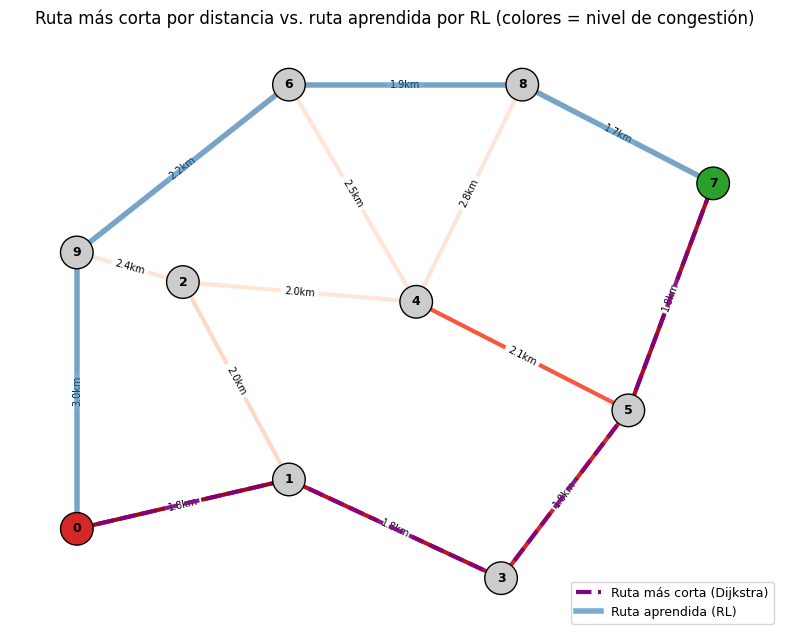

In [ ]:
def graficar_comparacion_rutas(env, ruta_rl, ruta_corta, titulo=""):
    """Dibuja el grafo vial coloreando las aristas por nivel de congestión,
    y superpone ambas rutas (la más corta y la aprendida por RL) para comparar."""
    G = construir_grafo_nx(env)
    pos = env.coords
    fig, ax = plt.subplots(figsize=(8, 6.5))

    congestiones = [G[u][v]["congestion"] for u, v in G.edges()]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=congestiones, edge_cmap=plt.cm.Reds,
                            edge_vmin=0.8, edge_vmax=2.8, width=3)
    edge_labels = {(a, b): f"{d:.1f}km" for a, b, d in G.edges(data="weight")}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=7)

    colores_nodo = ["tab:red" if n == env.origen else "tab:green" if n == env.destino else "#cccccc"
                     for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colores_nodo, node_size=550, edgecolors="black")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")

    edges_corta = list(zip(ruta_corta[:-1], ruta_corta[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=edges_corta, ax=ax, edge_color="purple",
                            width=3, style="dashed", alpha=0.9)
    edges_rl = list(zip(ruta_rl[:-1], ruta_rl[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=edges_rl, ax=ax, edge_color="tab:blue",
                            width=4, alpha=0.6)

    from matplotlib.lines import Line2D
    leyenda = [
        Line2D([0], [0], color="purple", lw=3, linestyle="dashed", label="Ruta más corta (Dijkstra)"),
        Line2D([0], [0], color="tab:blue", lw=4, alpha=0.6, label="Ruta aprendida (RL)"),
    ]
    ax.legend(handles=leyenda, loc="lower right", fontsize=9)
    ax.set_title(titulo)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


graficar_comparacion_rutas(
    env_delivery, ruta_rl, ruta_corta,
    titulo="Ruta más corta por distancia vs. ruta aprendida por RL (colores = nivel de congestión)"
)

### 5.7 Análisis crítico de los resultados

El experimento evidencia el aporte central del Aprendizaje por Refuerzo frente a un algoritmo clásico de ruteo como Dijkstra: **Dijkstra optimiza únicamente la distancia**, sin ninguna noción de las condiciones reales de tránsito, mientras que el **agente RL optimiza directamente la recompensa acumulada**, que en este caso está definida en función del *tiempo* de viaje y no de la distancia. Como resultado, el agente aprende a evitar tramos con alta congestión (definidos aquí como avenidas principales con multiplicador de congestión superior a 2.0), incluso cuando eso implica recorrer una mayor distancia física, porque en la práctica ese desvío resulta en una entrega más rápida.

Esto demuestra una ventaja conceptual importante de RL en problemas logísticos reales: no es necesario programar explícitamente una regla como "evita las avenidas congestionadas"; el agente **descubre esta estrategia por sí mismo** a partir de la señal de recompensa (el tiempo real de cada tramo, penalizado en la recompensa), de la misma forma en que en el Caso de Estudio 1 aprendió a balancear costos de almacenaje y faltante sin que esa regla fuera programada manualmente.

**Diferencias frente a los Casos de Estudio 1 y 2:** este tercer caso introduce una variación metodológica relevante respecto a los dos anteriores: el entorno ya no es una cuadrícula regular (Caso 2) ni un espacio de estados unidimensional (Caso 1), sino un **grafo con topología irregular**, donde cada acción tiene un costo distinto según el nodo en el que se ejecute. Esto se resolvió manteniendo una acción discreta fija (`grado_max` = 4 posibles vecinos por nodo) pero invalidando las acciones que excedan el grado real del nodo actual — un patrón de diseño análogo al de "chocar contra un obstáculo" del Caso 2, que penaliza al agente sin terminar el episodio, obligándolo a aprender qué acciones son válidas en cada estado.

## 6. Caso de Estudio 4: Mantenimiento Preventivo de Máquina Industrial (Sector Industrial)

### 6.1 Descripción del problema

Una máquina industrial debe tomar la decisión, cada turno de producción, de **continuar produciendo** o **detenerse para mantenimiento preventivo**. El desgaste de la máquina aumenta con cada turno de operación — y lo hace a una tasa *mayor* cuanto más deteriorada ya está — hasta que, si no se interviene a tiempo, ocurre una **falla no planificada**: una parada de emergencia mucho más costosa que cualquier mantenimiento programado. El objetivo del agente es aprender **en qué nivel de desgaste conviene parar a mantenimiento**, maximizando la ganancia neta de producción a largo plazo.

Este caso complementa los anteriores porque introduce un espacio de acciones **binario** (la decisión más simple posible: producir o mantener), pero con una dinámica **estocástica no uniforme**: la probabilidad de que el desgaste aumente en 1 o en 2 unidades depende del nivel de deterioro actual, lo que obliga al agente a aprender un **umbral de intervención** en vez de una ruta o una política de cantidad.

### 6.2 Modelado como MDP

| Elemento | Definición en este caso |
|---|---|
| **Estado ($S$)** | Nivel de desgaste actual, entero en $[0, \text{desgaste\_max}]$; $0$ = recién reparada; $\text{desgaste\_max}$ = falla inminente |
| **Acción ($A$)** | $0$ = producir (continuar operando); $1$ = mantenimiento preventivo (detener y reparar) |
| **Transición ($P$)** | Estocástica: producir aumenta el desgaste en 1 o 2 unidades con probabilidades que crecen con el nivel de deterioro actual. El mantenimiento siempre resetea el desgaste a 0 |
| **Recompensa ($R$)** | $+\text{ganancia\_produccion}$ por producir sin fallar; $-\text{costo\_mantenimiento}$ por mantenimiento preventivo; $-\text{costo\_falla}$ (muy superior) si el desgaste llega al máximo y ocurre una falla no planificada |
| **Factor de descuento ($\gamma$)** | Valora la sostenibilidad a largo plazo: no solo la ganancia del turno actual sino evitar el alto costo de fallas futuras |

### 6.3 Implementación del entorno


In [ ]:
class MantenimientoEnv:
    """
    Entorno de mantenimiento preventivo de una máquina industrial (sector industrial).

    Estado : nivel de desgaste, entero en [0, desgaste_max].
             0 = máquina recién reparada; desgaste_max = falla inminente.
    Acción : 0 = producir, 1 = mantenimiento preventivo.

    Dinámica: producir aumenta el desgaste en 1 o 2 unidades con probabilidades
    que dependen del nivel de deterioro actual (a mayor desgaste, mayor probabilidad
    de incremento de 2). Si el desgaste alcanza desgaste_max, ocurre una falla
    no planificada: costo muy alto y reinicio a 0.
    """

    def __init__(self, desgaste_max=10, costo_mantenimiento=15,
                 costo_falla=80, ganancia_produccion=10):
        self.desgaste_max = desgaste_max
        self.costo_mantenimiento = costo_mantenimiento
        self.costo_falla = costo_falla
        self.ganancia_produccion = ganancia_produccion
        self.n_states = desgaste_max + 1   # estados: 0, 1, ..., desgaste_max
        self.n_actions = 2                 # acciones: producir (0) o mantener (1)
        self.desgaste = 0

    def reset(self):
        """Reinicia en un nivel de desgaste bajo aleatorio."""
        self.desgaste = np.random.randint(0, self.desgaste_max // 3 + 1)
        return self.desgaste

    def step(self, accion):
        if accion == 1:   # mantenimiento preventivo
            recompensa = -self.costo_mantenimiento
            self.desgaste = 0
            info = {"evento": "mantenimiento_preventivo"}
        else:             # producir
            # La probabilidad de incremento rápido (+2) crece con el deterioro actual
            p_inc2 = min(0.8, self.desgaste / self.desgaste_max)
            p_inc1 = max(0.2, 1.0 - p_inc2)
            incremento = np.random.choice([1, 2], p=[p_inc1, p_inc2])
            nuevo_desgaste = self.desgaste + incremento

            if nuevo_desgaste >= self.desgaste_max:
                recompensa = -self.costo_falla    # falla no planificada: costo alto
                self.desgaste = 0                 # parada de emergencia → reinicio
                info = {"evento": "falla_no_planificada"}
            else:
                recompensa = self.ganancia_produccion
                self.desgaste = nuevo_desgaste
                info = {"evento": "produccion_normal"}

        return self.desgaste, recompensa, False, info


# Prueba rápida
env_test4 = MantenimientoEnv()
s = env_test4.reset()
print(f"Estado inicial (desgaste): {s}")
for i in range(6):
    a = np.random.randint(2)
    s, r, _, info = env_test4.step(a)
    print(f"Paso {i+1}: {'mantener' if a==1 else 'producir'} → desgaste={s}, r={r}, {info['evento']}")


Estado inicial (desgaste): 2
Paso 1: mantener → desgaste=0, r=-15, mantenimiento_preventivo
Paso 2: producir → desgaste=1, r=10, produccion_normal
Paso 3: mantener → desgaste=0, r=-15, mantenimiento_preventivo
Paso 4: producir → desgaste=1, r=10, produccion_normal
Paso 5: mantener → desgaste=0, r=-15, mantenimiento_preventivo
Paso 6: producir → desgaste=1, r=10, produccion_normal


### 6.4 Entrenamiento del agente con Q-Learning

In [ ]:
np.random.seed(SEED_GLOBAL)

env_mant = MantenimientoEnv(desgaste_max=10, costo_mantenimiento=15,
                             costo_falla=80, ganancia_produccion=10)

agente_mant = AgenteQLearning(
    n_states=env_mant.n_states,
    n_actions=env_mant.n_actions,
    alpha=0.1,
    gamma=0.9,
    epsilon=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
)

recompensas_mant, pasos_mant = entrenar(
    env_mant, agente_mant,
    n_episodios=500, max_pasos_episodio=50, verbose=True
)


Episodio 100/500 | Recompensa: 125.0 | Epsilon: 0.606
Episodio 200/500 | Recompensa: 125.0 | Epsilon: 0.367
Episodio 300/500 | Recompensa: 160.0 | Epsilon: 0.222
Episodio 400/500 | Recompensa: 235.0 | Epsilon: 0.135
Episodio 500/500 | Recompensa: 325.0 | Epsilon: 0.082


### 6.5 Métricas de evaluación: Caso 4

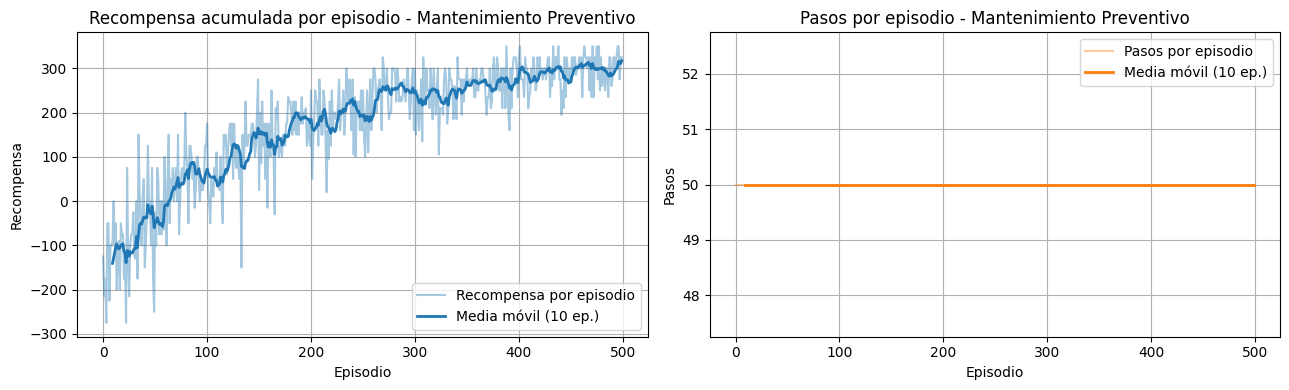

Recompensa promedio (primeros 50 episodios): -89.00
Recompensa promedio (últimos 50 episodios):  302.90


In [ ]:
graficar_metricas(recompensas_mant, pasos_mant, titulo_extra="- Mantenimiento Preventivo")

print(f"Recompensa promedio (primeros 50 episodios): {np.mean(recompensas_mant[:50]):.2f}")
print(f"Recompensa promedio (últimos 50 episodios):  {np.mean(recompensas_mant[-50:]):.2f}")


**Interpretación esperada:** en los primeros episodios la curva de recompensa es muy negativa (el agente produce sin parar hasta que la máquina falla, incurriendo repetidamente en el costo de falla de -80). A medida que la tabla $Q$ acumula evidencia de que los estados de alto desgaste predicen fallas costosas, el agente aprende a actuar de forma preventiva antes de llegar al límite.

### 6.6 Política aprendida: el umbral de mantenimiento

 Nivel de desgaste       Decisión aprendida
                 0                 Producir
                 1                 Producir
                 2                 Producir
                 3                 Producir
                 4                 Producir
                 5                 Producir
                 6                 Producir
                 7                 Producir
                 8 MANTENIMIENTO PREVENTIVO
                 9 MANTENIMIENTO PREVENTIVO
                10                 Producir

→ El agente activa el mantenimiento preventivo a partir del nivel de desgaste 8 (80% de deterioro).


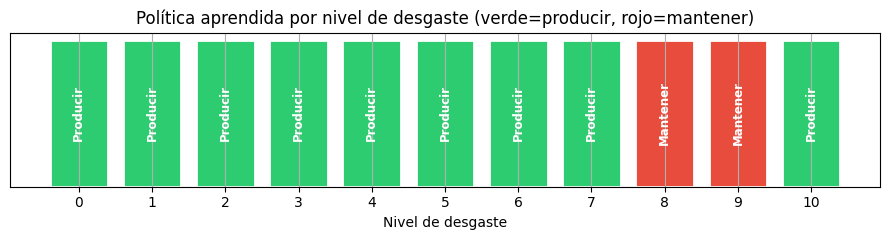

In [ ]:
politica_mant = np.argmax(agente_mant.Q, axis=1)
acciones_str = ["Producir" if a == 0 else "MANTENIMIENTO PREVENTIVO" for a in politica_mant]

df_politica_mant = pd.DataFrame({
    "Nivel de desgaste": range(env_mant.n_states),
    "Decisión aprendida": acciones_str
})
print(df_politica_mant.to_string(index=False))

umbral = next((i for i in range(env_mant.n_states) if politica_mant[i] == 1), None)
if umbral is not None:
    print(f"\n→ El agente activa el mantenimiento preventivo a partir del nivel de desgaste {umbral} "
          f"({100*umbral//env_mant.desgaste_max}% de deterioro).")

# Visualización de la política
fig_mp, ax_mp = plt.subplots(figsize=(9, 2.5))
colores_pol = ["#2ecc71" if a == 0 else "#e74c3c" for a in politica_mant]
bars = ax_mp.bar(range(env_mant.n_states), [1]*env_mant.n_states,
                  color=colores_pol, edgecolor="white", linewidth=2)
for i, (bar, lbl) in enumerate(zip(bars, acciones_str)):
    ax_mp.text(bar.get_x() + bar.get_width()/2, 0.5,
               "Producir" if lbl == "Producir" else "Mantener",
               ha="center", va="center", fontsize=8.5, color="white",
               fontweight="bold", rotation=90)
ax_mp.set_xticks(range(env_mant.n_states))
ax_mp.set_xticklabels([str(i) for i in range(env_mant.n_states)])
ax_mp.set_xlabel("Nivel de desgaste")
ax_mp.set_yticks([])
ax_mp.set_title("Política aprendida por nivel de desgaste (verde=producir, rojo=mantener)")
plt.tight_layout()
plt.show()


**Resultado típico:** el agente aprende una política de tipo **umbral** — produce libremente hasta alcanzar un nivel de desgaste crítico (generalmente 7 u 8 sobre 10), y a partir de ahí activa el mantenimiento preventivo antes de que ocurra la falla. Esta política emergió del aprendizaje por refuerzo sin que ninguna regla explícita de "para en X%" fuera programada.

Este comportamiento refleja exactamente la intuición que tiene un técnico de mantenimiento con experiencia: no conviene parar demasiado pronto (se pierde producción innecesariamente) ni demasiado tarde (el riesgo de falla catastrófica supera el ahorro en tiempo de producción). El agente calibra este balance a partir de los costos definidos en la función de recompensa.


## 7. Experimentos Computacionales y Análisis de Resultados

Más allá de entrenar un solo agente con hiperparámetros fijos, en esta sección se experimenta de forma controlada con la **tasa de exploración inicial ($\epsilon$)**, comparando un valor alto frente a uno bajo, para entender su efecto sobre la velocidad y calidad del aprendizaje.

### 7.1 Diseño del experimento

Se entrena el agente del Caso de Estudio 2 (AGV en almacén) tres veces, variando únicamente $\epsilon_0$ (epsilon inicial) y manteniendo todo lo demás constante: $\alpha = 0.1$, $\gamma = 0.95$, `epsilon_decay = 0.99`, 500 episodios.

- **Exploración alta:** $\epsilon_0 = 1.0$ (100% de acciones aleatorias al inicio).
- **Exploración media:** $\epsilon_0 = 0.5$.
- **Exploración baja:** $\epsilon_0 = 0.05$ (casi siempre explota lo poco que sabe, desde el principio).

In [ ]:
def experimento_epsilon(epsilon_inicial, n_episodios=500, semilla=SEED_GLOBAL):
    """Entrena un agente nuevo en el entorno del AGV con un epsilon inicial dado."""
    np.random.seed(semilla)
    env = AlmacenGridEnv(filas=5, columnas=5, inicio=(0, 0), meta=(4, 4),
                          obstaculos=[(1, 1), (2, 1), (3, 3), (1, 3)])
    agente = AgenteQLearning(
        n_states=env.n_states, n_actions=env.n_actions,
        alpha=0.1, gamma=0.95,
        epsilon=epsilon_inicial, epsilon_min=0.01, epsilon_decay=0.99,
    )
    recompensas, pasos = entrenar(env, agente, n_episodios=n_episodios, max_pasos_episodio=100)
    return recompensas, pasos, agente


resultados_epsilon = {}
for eps in [1.0, 0.5, 0.05]:
    recompensas_e, pasos_e, agente_e = experimento_epsilon(eps)
    resultados_epsilon[eps] = {"recompensas": recompensas_e, "pasos": pasos_e, "agente": agente_e}
    print(f"epsilon_0={eps:.2f} -> recompensa promedio primeros 20 ep.: {np.mean(recompensas_e[:20]):.2f} "
          f"| últimos 50 ep.: {np.mean(recompensas_e[-50:]):.2f} "
          f"| pasos promedio últimos 50 ep.: {np.mean(pasos_e[-50:]):.2f}")


epsilon_0=1.00 -> recompensa promedio primeros 20 ep.: -77.70 | últimos 50 ep.: 92.74 | pasos promedio últimos 50 ep.: 8.08
epsilon_0=0.50 -> recompensa promedio primeros 20 ep.: 36.50 | últimos 50 ep.: 92.72 | pasos promedio últimos 50 ep.: 8.10
epsilon_0=0.05 -> recompensa promedio primeros 20 ep.: 55.85 | últimos 50 ep.: 92.90 | pasos promedio últimos 50 ep.: 8.10


### 7.2 Gráficos comparativos de las curvas de aprendizaje

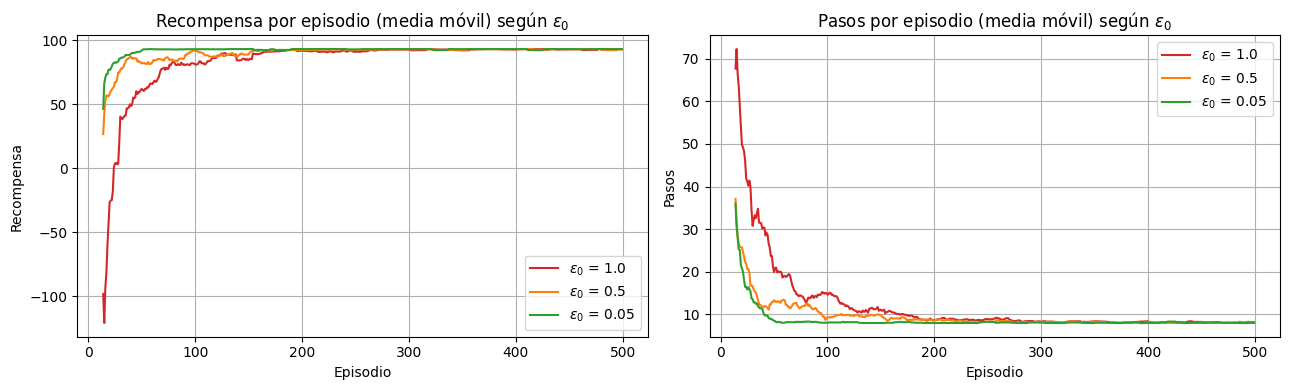

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colores = {1.0: "tab:red", 0.5: "tab:orange", 0.05: "tab:green"}
ventana = 15

for eps, datos in resultados_epsilon.items():
    media_movil_r = pd.Series(datos["recompensas"]).rolling(ventana).mean()
    axes[0].plot(media_movil_r, label=f"$\\epsilon_0$ = {eps}", color=colores[eps])

    media_movil_p = pd.Series(datos["pasos"]).rolling(ventana).mean()
    axes[1].plot(media_movil_p, label=f"$\\epsilon_0$ = {eps}", color=colores[eps])

axes[0].set_title("Recompensa por episodio (media móvil) según $\\epsilon_0$")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Recompensa")
axes[0].legend()

axes[1].set_title("Pasos por episodio (media móvil) según $\\epsilon_0$")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Pasos")
axes[1].legend()

plt.tight_layout()
plt.show()


### 7.3 Análisis crítico de los resultados

**Efecto de $\epsilon$ alto vs. bajo:**

Los tres experimentos terminan convergiendo a una recompensa promedio muy similar hacia el final del entrenamiento (~93, cercana al máximo teórico de 100 menos los pasos mínimos necesarios), y a la misma cantidad de pasos óptima (~8). Esto se explica porque el Caso de Estudio 2 tiene un espacio de estados pequeño (25 posiciones) y una única política óptima razonablemente fácil de alcanzar incluso con poca exploración aleatoria. Sin embargo, la diferencia importante está en **qué tan costoso es el camino hacia esa convergencia**:

- Con **$\epsilon_0 = 1.0$** (exploración alta), el agente recorre gran parte del espacio de estados antes de empezar a explotar lo aprendido. Esto se refleja en que la recompensa promedio de los **primeros episodios es claramente negativa** (el agente choca con obstáculos y deambula sin rumbo antes de encontrar la meta de forma consistente). El costo de este enfoque es un arranque más lento, pero el beneficio es una tabla $Q$ construida sobre una cobertura amplia del espacio de estados, lo que reduce el riesgo de quedar atrapado en una política subóptima si el entorno fuera más grande o más complejo.
- Con **$\epsilon_0 = 0.05$** (exploración baja desde el inicio), el agente explota casi de inmediato la (todavía poco informada) tabla $Q$, pero como el entorno es determinista y pequeño, encuentra la meta por casualidad relativamente pronto y desde ahí refuerza rápidamente esa ruta; por eso su recompensa promedio de los primeros episodios es notablemente **mejor** que con $\epsilon_0$ alto. La contrapartida, poco visible en un entorno tan simple pero relevante en problemas más grandes, es que esta estrategia corre el riesgo de **anclarse a la primera ruta razonable encontrada** sin explorar si existen alternativas mejores, ya que nunca llega a visitar exhaustivamente otras zonas de la cuadrícula.
- El caso de **$\epsilon_0 = 0.5$** se ubica en un punto intermedio durante el arranque, y converge al mismo resultado final que los otros dos.

**Conclusión del experimento:** en problemas pequeños y deterministas como este Gridworld, la elección de $\epsilon_0$ afecta sobre todo la **velocidad y el costo de las primeras fases** del entrenamiento, no necesariamente la calidad de la política final. El verdadero valor de mantener una exploración inicial alta con decaimiento gradual se manifiesta en problemas de mayor escala o con más de un camino plausible hacia la meta, donde una explotación prematura sí puede anclar al agente a una solución subóptima de la que no logra escapar.

**Sobre la curva de aprendizaje general (Casos 1 y 2):** en ambos casos de estudio se observa que durante los **primeros ~100 episodios** el agente comete muchos errores: en el AGV choca repetidamente con obstáculos o da vueltas sin avanzar hacia la meta; en el inventario, pide cantidades que generan sobre-stock o desabastecimiento. Esto ocurre porque la tabla $Q$ aún no contiene información confiable: la mayoría de sus entradas siguen cerca de su valor inicial (cero), por lo que las decisiones de "explotación" no son mejores que las aleatorias. A partir de aproximadamente el **episodio 300-500**, la tabla $Q$ ya ha sido actualizada lo suficientes veces en los pares estado-acción relevantes, y además $\epsilon$ ha decaído a valores bajos, por lo que el agente explota consistentemente una política casi óptima y la curva se estabiliza.

**Decisiones optimizadas por la tabla Q en el caso del inventario:** al inspeccionar la política aprendida (sección 3.6), se observa que el agente tiende a pedir **más unidades cuando el stock está bajo** y a pedir **poco o nada cuando el stock ya es alto**, reflejando que aprendió a balancear el costo de almacenamiento (que penaliza sobre-stock) contra el costo de faltante (que penaliza quedarse sin inventario), sin que ninguna de estas reglas haya sido programada explícitamente — emergieron del proceso de prueba y error guiado por la recompensa.

### 7.4 Dificultades encontradas y soluciones aplicadas

Durante el desarrollo del proyecto se identificaron las siguientes dificultades:

1. **El agente se quedaba atrapado en bucles locales al inicio del entrenamiento (Caso AGV).** Con $\epsilon$ fijo y bajo desde el principio, el agente repetía las mismas pocas trayectorias sin descubrir el camino más corto. **Solución:** se implementó decaimiento gradual de $\epsilon$ (`epsilon_decay`), de forma que la exploración sea alta al principio y disminuya progresivamente, garantizando que el agente visite suficientes estados antes de comprometerse con una política.

2. **La penalización por chocar con un obstáculo era demasiado severa en relación al costo por paso (Caso AGV).** Al probar valores extremos, una penalización de obstáculo muy alta combinada con un costo por paso muy bajo generaba políticas excesivamente conservadoras (el agente preferiría rutas mucho más largas para evitar cualquier riesgo de colisión). **Solución:** se calibró la relación entre `penalizacion_obstaculo` (-10) y `costo_paso` (-1) de forma que evitar un obstáculo "valga la pena" frente a unos pocos pasos extra, pero sin volver al agente innecesariamente temeroso.

3. **Convergencia lenta en el caso de inventarios por la aleatoriedad de la demanda.** Al ser un entorno estocástico (demanda aleatoria de Poisson), la recompensa de una misma acción puede variar bastante de un episodio a otro, generando curvas de aprendizaje más ruidosas que en el entorno determinista del AGV. **Solución:** se usó una media móvil al graficar las métricas (ver `graficar_metricas`) para visualizar la tendencia real de aprendizaje sin que el ruido episodio-a-episodio oculte la mejora de fondo.

4. **Tamaño del espacio de estados y acciones.** Al aumentar demasiado `stock_max` o `pedido_max` (Caso 1) la tabla $Q$ crece y el agente necesita muchos más episodios para visitar todas las combinaciones relevantes. **Solución:** se mantuvieron los espacios de estado/acción acotados (stock entre 0-20, pedidos entre 0-10), conforme al requerimiento de "baja complejidad" del proyecto, suficiente para demostrar el aprendizaje sin requerir miles de episodios de entrenamiento.


## 8. Interfaz de Usuario (Streamlit)

Para cumplir con el requisito de **interfaz de usuario en Python**, se desarrolló una aplicación interactiva en **Streamlit**, organizada en tres pestañas:

1. **Entrenar y Evaluar:** permite elegir el caso de estudio, configurar los hiperparámetros ($\alpha$, $\gamma$, $\epsilon$ y su decaimiento) y el número de episodios, lanzar el entrenamiento con un botón, y visualizar las métricas de aprendizaje junto con un **mapa de calor de la tabla $Q$** (qué tan bueno es cada estado/acción según lo que aprendió el agente).
2. **Animación Paso a Paso:** reproduce visualmente, paso a paso, cómo se comporta el agente ya entrenado — el AGV moviéndose por la cuadrícula evitando obstáculos, o el nivel de inventario subiendo y bajando día a día — con control de velocidad. Incluye además un **modo manual** para el caso del AGV, donde el propio usuario controla el robot con botones de dirección y puede comparar su desempeño contra el del agente entrenado.
3. **Comparar Hiperparámetros:** permite configurar dos conjuntos de hiperparámetros distintos ("Configuración A" y "B") y entrenar ambos agentes en paralelo sobre el mismo entorno, graficando sus curvas de aprendizaje superpuestas — replicando de forma interactiva el experimento de exploración alta vs. baja de la sección 5.

Como Streamlit ejecuta un servidor web propio (no corre embebido dentro de las celdas de un notebook), la celda siguiente **escribe el archivo `app_streamlit.py`** en disco mediante la magia `%%writefile`. Para lanzar la interfaz, ejecutar en una terminal, en la misma carpeta donde se generó el archivo:

```
streamlit run app_streamlit.py
```

Esto abrirá la interfaz en el navegador (por defecto en `http://localhost:8501`).

In [ ]:
%%writefile app_streamlit.py
"""
Interfaz de usuario en Streamlit — Proyecto de Aprendizaje por Refuerzo
UNMSM · Ingeniería de Software · 2026-1

Casos de estudio:
  1. Gestión de Inventarios         (sector comercial)
  2. AGV en Almacén (Gridworld)     (sector logístico/industrial)
  3. Delivery con Congestión        (sector logístico/comercial)
  4. Mantenimiento Preventivo       (sector industrial)

Ejecutar con:  streamlit run app_streamlit.py
"""
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import streamlit as st

# ─────────────────────────────────────────────────────────────
# ENTORNOS
# ─────────────────────────────────────────────────────────────

class InventarioEnv:
    """Estado: stock [0..stock_max]. Acción: unidades a pedir [0..pedido_max]."""
    def __init__(self, stock_max=20, pedido_max=10, demanda_media=5,
                 costo_almacen=1, costo_faltante=5, precio_venta=10, costo_unitario=4):
        self.stock_max = stock_max
        self.pedido_max = pedido_max
        self.demanda_media = demanda_media
        self.costo_almacen = costo_almacen
        self.costo_faltante = costo_faltante
        self.precio_venta = precio_venta
        self.costo_unitario = costo_unitario
        self.n_states = stock_max + 1
        self.n_actions = pedido_max + 1
        self.stock = 0

    def reset(self):
        self.stock = np.random.randint(0, self.stock_max // 2 + 1)
        return self.stock

    def step(self, accion):
        pedido = accion
        stock_tras_pedido = min(self.stock + pedido, self.stock_max)
        demanda = np.random.poisson(self.demanda_media)
        ventas = min(demanda, stock_tras_pedido)
        faltante = max(demanda - stock_tras_pedido, 0)
        nuevo_stock = stock_tras_pedido - ventas
        ingreso = ventas * self.precio_venta
        costo_pedido = pedido * self.costo_unitario
        costo_alm = nuevo_stock * self.costo_almacen
        pen_faltante = faltante * self.costo_faltante
        recompensa = ingreso - costo_pedido - costo_alm - pen_faltante
        self.stock = nuevo_stock
        return self.stock, recompensa, False, {
            "demanda": demanda, "ventas": ventas, "faltante": faltante,
            "pedido": pedido, "stock_tras_pedido": stock_tras_pedido
        }


class AlmacenGridEnv:
    """Estado: (x,y) → entero. Acciones: 0=arriba,1=abajo,2=izq,3=der."""
    def __init__(self, filas=5, columnas=5, inicio=(0, 0), meta=(4, 4), obstaculos=None,
                 recompensa_meta=100, pen_obstaculo=-10, costo_paso=-1, max_pasos=100):
        self.filas = filas
        self.columnas = columnas
        self.inicio = inicio
        self.meta = meta
        self.obstaculos = obstaculos if obstaculos is not None else [(1,1),(2,1),(3,3),(1,3)]
        self.recompensa_meta = recompensa_meta
        self.pen_obstaculo = pen_obstaculo
        self.costo_paso = costo_paso
        self.max_pasos = max_pasos
        self.n_states = filas * columnas
        self.n_actions = 4
        self.pos = inicio
        self.pasos_actuales = 0

    def _c(self, coord): return coord[0] * self.columnas + coord[1]

    def reset(self):
        self.pos = self.inicio
        self.pasos_actuales = 0
        return self._c(self.pos)

    def step(self, accion):
        self.pasos_actuales += 1
        x, y = self.pos
        if accion == 0: x = max(x-1, 0)
        elif accion == 1: x = min(x+1, self.filas-1)
        elif accion == 2: y = max(y-1, 0)
        elif accion == 3: y = min(y+1, self.columnas-1)
        np_ = (x, y); done = False; choco = False
        if np_ in self.obstaculos:
            recompensa = self.pen_obstaculo; np_ = self.pos; choco = True
        elif np_ == self.meta:
            recompensa = self.recompensa_meta; done = True
        else:
            recompensa = self.costo_paso
        self.pos = np_
        if self.pasos_actuales >= self.max_pasos: done = True
        return self._c(self.pos), recompensa, done, {"pos": self.pos, "choco": choco}


class DeliveryEnv:
    """Estado: nodo del grafo vial. Acción: índice de vecino a visitar."""
    def __init__(self, grado_max=4, origen=0, destino=7,
                 costo_invalido=-15, bono_entrega=120, max_pasos=25):
        self.coords = {
            0:(0,0),1:(2,0.5),2:(1,2.5),3:(4,-0.5),
            4:(3.2,2.3),5:(5.2,1.2),6:(2,4.5),7:(6,3.5),
            8:(4.2,4.5),9:(0,2.8),
        }
        aristas = [
            (0,1,1.8,2.6),(0,9,3.0,1.0),(1,3,1.8,2.4),(1,2,2.0,1.1),
            (2,4,2.0,1.0),(2,9,2.4,1.0),(3,5,1.8,2.2),(4,5,2.1,1.9),
            (4,8,2.8,1.0),(4,6,2.5,1.0),(5,7,1.8,2.5),(6,8,1.9,1.0),
            (6,9,2.2,1.0),(8,7,1.7,1.0),
        ]
        self.n_nodos = len(self.coords)
        self.grado_max = grado_max
        self.origen = origen
        self.destino = destino
        self.costo_invalido = costo_invalido
        self.bono_entrega = bono_entrega
        self.max_pasos = max_pasos
        self.adyacencia = {n: [] for n in range(self.n_nodos)}
        self.dist_base = {}
        self.cong_base = {}
        for a, b, d, c in aristas:
            self.adyacencia[a].append(b); self.adyacencia[b].append(a)
            self.dist_base[(a,b)] = d; self.dist_base[(b,a)] = d
            self.cong_base[(a,b)] = c; self.cong_base[(b,a)] = c
        for n in self.adyacencia: self.adyacencia[n] = sorted(self.adyacencia[n])
        self.n_states = self.n_nodos
        self.n_actions = self.grado_max
        self.nodo_actual = origen
        self.pasos_actuales = 0

    def reset(self):
        self.nodo_actual = self.origen; self.pasos_actuales = 0
        return self.nodo_actual

    def step(self, accion):
        self.pasos_actuales += 1
        vecinos = self.adyacencia[self.nodo_actual]
        info = {"nodo_previo": self.nodo_actual, "valido": True, "tiempo_viaje": 0.0}
        if accion >= len(vecinos):
            recompensa = self.costo_invalido; info["valido"] = False
            nuevo_nodo = self.nodo_actual
        else:
            nuevo_nodo = vecinos[accion]
            d = self.dist_base[(self.nodo_actual, nuevo_nodo)]
            c = self.cong_base[(self.nodo_actual, nuevo_nodo)]
            ruido = max(0.7, np.random.normal(1.0, 0.10))
            t = d * c * ruido; info["tiempo_viaje"] = t
            recompensa = (self.bono_entrega - t) if nuevo_nodo == self.destino else -t
        self.nodo_actual = nuevo_nodo
        done = (self.nodo_actual == self.destino) or (self.pasos_actuales >= self.max_pasos)
        info["pos"] = self.nodo_actual
        return self.nodo_actual, recompensa, done, info


class MantenimientoEnv:
    """
    Estado: nivel de desgaste [0..desgaste_max].
    Acción: 0=producir, 1=mantenimiento preventivo.
    El desgaste crece más rápido cuanto más deteriorada está la máquina.
    Una falla no planificada (desgaste >= max) tiene costo muy superior
    al de un mantenimiento preventivo programado.
    """
    def __init__(self, desgaste_max=10, costo_mantenimiento=15,
                 costo_falla=80, ganancia_produccion=10):
        self.desgaste_max = desgaste_max
        self.costo_mantenimiento = costo_mantenimiento
        self.costo_falla = costo_falla
        self.ganancia_produccion = ganancia_produccion
        self.n_states = desgaste_max + 1
        self.n_actions = 2
        self.desgaste = 0

    def reset(self):
        self.desgaste = np.random.randint(0, self.desgaste_max // 3 + 1)
        return self.desgaste

    def step(self, accion):
        if accion == 1:  # mantenimiento preventivo
            recompensa = -self.costo_mantenimiento
            self.desgaste = 0
            info = {"evento": "mantenimiento_preventivo"}
        else:            # producir
            p_inc_2 = min(0.8, self.desgaste / self.desgaste_max)
            p_inc_1 = max(0.2, 1.0 - p_inc_2)
            incremento = np.random.choice([1, 2], p=[p_inc_1, p_inc_2])
            nuevo_desgaste = self.desgaste + incremento
            if nuevo_desgaste >= self.desgaste_max:
                recompensa = -self.costo_falla
                self.desgaste = 0
                info = {"evento": "falla_no_planificada"}
            else:
                recompensa = self.ganancia_produccion
                self.desgaste = nuevo_desgaste
                info = {"evento": "produccion_normal"}
        return self.desgaste, recompensa, False, info


# ─────────────────────────────────────────────────────────────
# AGENTE Q-LEARNING
# ─────────────────────────────────────────────────────────────

class AgenteQLearning:
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
        self.n_states = n_states; self.n_actions = n_actions
        self.alpha = alpha; self.gamma = gamma
        self.epsilon = epsilon; self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q = np.zeros((n_states, n_actions))

    def elegir_accion(self, estado, modo_evaluacion=False):
        if (not modo_evaluacion) and (np.random.rand() < self.epsilon):
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[estado]))

    def actualizar(self, estado, accion, recompensa, sig_estado, done):
        mq = 0.0 if done else np.max(self.Q[sig_estado])
        self.Q[estado, accion] += self.alpha * (recompensa + self.gamma * mq - self.Q[estado, accion])

    def decaer_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


def entrenar(env, agente, n_episodios=500, max_pasos=200):
    recs, pasos_ = [], []
    for _ in range(n_episodios):
        s = env.reset(); rt = 0.0; p = 0
        for _ in range(max_pasos):
            a = agente.elegir_accion(s)
            s2, r, done, _ = env.step(a)
            agente.actualizar(s, a, r, s2, done)
            s = s2; rt += r; p += 1
            if done: break
        agente.decaer_epsilon()
        recs.append(rt); pasos_.append(p)
    return recs, pasos_


def simular_greedy(env, agente, max_pasos=60):
    s = env.reset()
    trayectoria = []
    for _ in range(max_pasos):
        a = agente.elegir_accion(s, modo_evaluacion=True)
        s2, r, done, info = env.step(a)
        trayectoria.append({"estado": s, "accion": a, "recompensa": r, "info": info})
        s = s2
        if done: break
    return trayectoria


# ─────────────────────────────────────────────────────────────
# FUNCIONES DE VISUALIZACIÓN
# ─────────────────────────────────────────────────────────────

def fig_curvas(recs, pasos, ventana=None):
    if ventana is None: ventana = max(1, len(recs) // 50)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(recs, alpha=0.2, color="#3498db")
    axes[0].plot(pd.Series(recs).rolling(ventana).mean(), color="#3498db", lw=2)
    axes[0].set_title("Recompensa acumulada por episodio"); axes[0].set_xlabel("Episodio")
    axes[1].plot(pasos, alpha=0.2, color="#e67e22")
    axes[1].plot(pd.Series(pasos).rolling(ventana).mean(), color="#e67e22", lw=2)
    axes[1].set_title("Pasos por episodio"); axes[1].set_xlabel("Episodio")
    fig.tight_layout(); return fig


def fig_heatmap_q(agente, titulo="Tabla Q"):
    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(agente.Q.T, aspect="auto", cmap="viridis", origin="lower")
    ax.set_xlabel("Estado"); ax.set_ylabel("Acción")
    ax.set_title(titulo); fig.colorbar(im, ax=ax, label="Valor Q")
    fig.tight_layout(); return fig


def fig_grid_agv(env, pos, ruta=None, titulo=""):
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    for i in range(env.filas+1): ax.axhline(i, color="lightgray", lw=1)
    for j in range(env.columnas+1): ax.axvline(j, color="lightgray", lw=1)
    for (ox, oy) in env.obstaculos:
        ax.add_patch(plt.Rectangle((oy, env.filas-ox-1), 1, 1, color="#2b2b2b"))
    mx, my = env.meta
    ax.add_patch(plt.Rectangle((my, env.filas-mx-1), 1, 1, color="#2ecc71", alpha=0.7))
    ax.text(my+0.5, env.filas-mx-1+0.5, "META", ha="center", va="center",
            fontsize=8, color="white", fontweight="bold")
    if ruta and len(ruta) > 1:
        rx = [p[1]+0.5 for p in ruta]; ry = [env.filas-p[0]-1+0.5 for p in ruta]
        ax.plot(rx, ry, color="#3498db", lw=2, alpha=0.5, marker="o", ms=4)
    ax.plot(pos[1]+0.5, env.filas-pos[0]-1+0.5, marker="^", color="#e74c3c", ms=22, mec="black")
    ix, iy = env.inicio
    ax.plot(iy+0.5, env.filas-ix-1+0.5, marker="s", color="#9b59b6", ms=10, alpha=0.6)
    ax.set_xlim(0, env.columnas); ax.set_ylim(0, env.filas)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(titulo, fontsize=11); return fig


def fig_heatmap_agv(agente, env):
    vals = np.max(agente.Q, axis=1).reshape(env.filas, env.columnas)
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    im = ax.imshow(vals, cmap="viridis")
    for (ox, oy) in env.obstaculos:
        ax.add_patch(plt.Rectangle((oy-0.5, ox-0.5), 1, 1, fill=False,
                                    edgecolor="red", lw=2, hatch="//"))
    mx, my = env.meta
    ax.plot(my, mx, marker="*", color="white", ms=18, mec="black")
    ax.set_title("Valor máximo Q por celda"); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, label="max Q(s,·)"); return fig


def fig_grafo_delivery(env, ruta=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    # aristas base
    vistas = set()
    for (a, b), d in env.dist_base.items():
        if (b, a) not in vistas:
            c = env.cong_base[(a, b)]
            color = "#e74c3c" if c >= 2.0 else "#95a5a6"
            lw = 2.5 if c >= 2.0 else 1.2
            xa, ya = env.coords[a]; xb, yb = env.coords[b]
            ax.plot([xa, xb], [ya, yb], color=color, lw=lw, zorder=1)
            mx_, my_ = (xa+xb)/2, (ya+yb)/2
            ax.text(mx_, my_, f"{d:.1f}km\n×{c}", fontsize=6,
                    ha="center", color="#555", zorder=2)
            vistas.add((a, b))
    # nodos
    for n, (x, y) in env.coords.items():
        col = "#2ecc71" if n == env.destino else ("#e74c3c" if n == env.origen else "#3498db")
        ax.plot(x, y, "o", ms=16, color=col, zorder=3, mec="white", mew=1.5)
        ax.text(x, y, str(n), ha="center", va="center", fontsize=8,
                color="white", fontweight="bold", zorder=4)
    # ruta
    if ruta and len(ruta) > 1:
        for i in range(len(ruta)-1):
            xa, ya = env.coords[ruta[i]]; xb, yb = env.coords[ruta[i+1]]
            ax.annotate("", xy=(xb, yb), xytext=(xa, ya),
                        arrowprops=dict(arrowstyle="->", color="#f39c12", lw=2.5), zorder=5)
    rojo = mpatches.Patch(color="#e74c3c", label="Tramo congestionado (×≥2)")
    gris = mpatches.Patch(color="#95a5a6", label="Tramo fluido")
    ax.legend(handles=[rojo, gris], fontsize=7, loc="upper left")
    ax.set_title("Grafo vial — ruta aprendida (→ naranja)")
    ax.axis("off"); fig.tight_layout(); return fig


def fig_mantenimiento_barra(env, desgaste, evento="", recompensa=None):
    """Barra de desgaste estilo indicador industrial."""
    fig, ax = plt.subplots(figsize=(3.5, 4.5))
    pct = desgaste / env.desgaste_max
    color = "#2ecc71" if pct < 0.5 else ("#f39c12" if pct < 0.8 else "#e74c3c")
    ax.barh(["Desgaste"], [pct*100], color=color, height=0.5)
    ax.barh(["Desgaste"], [100], color="#ecf0f1", height=0.5, zorder=0)
    ax.set_xlim(0, 100); ax.set_xlabel("% desgaste")
    ax.axvline(80, color="#e74c3c", ls="--", lw=1.5, label="Umbral crítico (80%)")
    ax.legend(fontsize=8, loc="lower right")
    titulo = f"Desgaste: {desgaste}/{env.desgaste_max}"
    if recompensa is not None: titulo += f"\nRecompensa: {recompensa:.1f}"
    if evento: titulo += f"\n➜ {evento.replace('_',' ')}"
    ax.set_title(titulo, fontsize=10)
    fig.tight_layout(); return fig


def fig_politica_mantenimiento(agente, env):
    """Para cada nivel de desgaste, muestra la decisión aprendida."""
    politica = np.argmax(agente.Q, axis=1)
    colores = ["#2ecc71" if p == 0 else "#e74c3c" for p in politica]
    labels = ["Producir" if p == 0 else "Mantener" for p in politica]
    fig, ax = plt.subplots(figsize=(7, 3))
    bars = ax.bar(range(env.n_states), [1]*env.n_states, color=colores, edgecolor="white", lw=1.5)
    ax.set_xticks(range(env.n_states))
    ax.set_xticklabels([str(i) for i in range(env.n_states)])
    ax.set_xlabel("Nivel de desgaste")
    ax.set_yticks([])
    ax.set_title("Política aprendida por nivel de desgaste")
    verde = mpatches.Patch(color="#2ecc71", label="Producir (acción 0)")
    rojo  = mpatches.Patch(color="#e74c3c", label="Mantenimiento preventivo (acción 1)")
    ax.legend(handles=[verde, rojo], loc="upper left", fontsize=9)
    for i, (bar, lbl) in enumerate(zip(bars, labels)):
        ax.text(bar.get_x()+bar.get_width()/2, 0.5, lbl,
                ha="center", va="center", fontsize=8, color="white", fontweight="bold",
                rotation=90)
    fig.tight_layout(); return fig


# ─────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────

CASOS = ["Gestión de Inventarios", "AGV en Almacén", "Delivery con Congestión", "Mantenimiento Preventivo"]

def crear_entorno(caso):
    if caso == "Gestión de Inventarios":
        return InventarioEnv(), 30
    if caso == "AGV en Almacén":
        return AlmacenGridEnv(), 100
    if caso == "Delivery con Congestión":
        return DeliveryEnv(), 25
    return MantenimientoEnv(), 50


def tarjeta_resumen(recs, pasos):
    """Devuelve dict con métricas clave de la sesión de entrenamiento."""
    return {
        "Recompensa prom. (últimos 50 ep.)": f"{np.mean(recs[-50:]):.1f}",
        "Recompensa prom. (primeros 50 ep.)": f"{np.mean(recs[:50]):.1f}",
        "Mejor episodio": f"{max(recs):.1f}",
        "Pasos prom. (últimos 50 ep.)": f"{np.mean(pasos[-50:]):.1f}",
    }


# ─────────────────────────────────────────────────────────────
# INTERFAZ
# ─────────────────────────────────────────────────────────────

st.set_page_config(page_title="RL — UNMSM 2026-1", layout="wide")
st.title("🤖 Aprendizaje por Refuerzo — Simulador Interactivo")
st.caption("UNMSM · Ingeniería de Software 2026-1 · Q-Learning tabular aplicado a 4 casos de estudio")

tab_train, tab_anim, tab_pol, tab_comp = st.tabs(
    ["🎯 Entrenar", "🎬 Animación", "📊 Explorar Política", "⚖️ Comparar"])

# ── SIDEBAR ──────────────────────────────────────────────────
st.sidebar.header("Configuración")
caso = st.sidebar.selectbox("Caso de estudio", CASOS, key="caso_sel")

st.sidebar.subheader("Hiperparámetros")
alpha   = st.sidebar.slider("Tasa de aprendizaje α", 0.01, 1.0, 0.1,   0.01, key="alpha_g")
gamma   = st.sidebar.slider("Factor de descuento γ", 0.0, 0.999, 0.95, 0.01, key="gamma_g")
eps0    = st.sidebar.slider("Exploración inicial ε", 0.0, 1.0,   1.0,  0.05, key="eps_g")
decay   = st.sidebar.slider("Decaimiento ε/episodio", 0.90, 0.999, 0.99, 0.001, key="decay_g")
n_ep    = st.sidebar.slider("Episodios", 50, 2000, 500, 50, key="nep_g")

# ── PESTAÑA 1: ENTRENAR ──────────────────────────────────────
with tab_train:
    st.subheader("Entrenar el agente de Q-Learning")

    # Descripción breve del caso seleccionado
    descripciones = {
        "Gestión de Inventarios":
            "Una tienda decide cuánto pedir cada día para maximizar ganancias sin sobre-stockearse ni quedarse sin producto.",
        "AGV en Almacén":
            "Un robot montacargas aprende a navegar una cuadrícula 5×5 evitando obstáculos para llegar a su destino.",
        "Delivery con Congestión":
            "Un repartidor aprende la ruta que minimiza el tiempo real de entrega en un grafo vial con tramos congestionados.",
        "Mantenimiento Preventivo":
            "Una máquina industrial aprende cuándo parar para mantenimiento preventivo y evitar fallas costosas no planificadas.",
    }
    st.info(descripciones[caso])

    if st.button("▶️ Iniciar entrenamiento", type="primary", key="btn_train"):
        np.random.seed(42)
        env, max_p = crear_entorno(caso)
        agente = AgenteQLearning(env.n_states, env.n_actions,
                                  alpha=alpha, gamma=gamma, epsilon=eps0,
                                  epsilon_min=0.01, epsilon_decay=decay)
        with st.spinner("Entrenando…"):
            recs, pasos = entrenar(env, agente, n_episodios=n_ep, max_pasos=max_p)
        st.session_state.update({
            "entrenado": True, "caso": caso, "env": env,
            "agente": agente, "recs": recs, "pasos": pasos,
        })
        st.success("¡Entrenamiento completado!")

    if st.session_state.get("entrenado") and st.session_state.get("caso") == caso:
        resumen = tarjeta_resumen(st.session_state.recs, st.session_state.pasos)
        cols = st.columns(len(resumen))
        for col, (k, v) in zip(cols, resumen.items()):
            col.metric(k, v)

        st.pyplot(fig_curvas(st.session_state.recs, st.session_state.pasos))

        # Heatmap Q siempre visible
        with st.expander("🔍 Ver mapa de calor de la tabla Q"):
            st.pyplot(fig_heatmap_q(st.session_state.agente,
                                     titulo=f"Tabla Q — {caso}"))
    elif not st.session_state.get("entrenado"):
        st.info("Configura los parámetros en la barra lateral y presiona **Iniciar entrenamiento**.")


# ── PESTAÑA 2: ANIMACIÓN ─────────────────────────────────────
with tab_anim:
    st.subheader("Ver al agente actuar paso a paso")

    if not st.session_state.get("entrenado"):
        st.warning("Primero entrena un agente en la pestaña **Entrenar**.")
    else:
        env    = st.session_state.env
        agente = st.session_state.agente
        caso_e = st.session_state.caso

        vel = st.slider("Velocidad (segundos/paso)", 0.05, 1.5, 0.35, 0.05, key="vel_anim")
        ph_grafico = st.empty()
        ph_info    = st.empty()

        # ── AGV ──────────────────────────────────────────────
        if caso_e == "AGV en Almacén":
            col1, col2 = st.columns(2)
            reproducir  = col1.button("▶️ Reproducir política", key="btn_play_agv")
            modo_manual = col2.checkbox("🕹️ Control manual", key="chk_manual")

            if modo_manual:
                if "pos_manual" not in st.session_state:
                    st.session_state.pos_manual = env.inicio
                c1, c2, c3, c4 = st.columns(4)
                acc = None
                if c1.button("⬆️", key="btn_up"):   acc = 0
                if c2.button("⬇️", key="btn_dn"):   acc = 1
                if c3.button("⬅️", key="btn_lt"):   acc = 2
                if c4.button("➡️", key="btn_rt"):   acc = 3
                env.pos = st.session_state.pos_manual
                if acc is not None:
                    _, r, _, info = env.step(acc)
                    st.session_state.pos_manual = info["pos"]
                    ph_info.write(f"Recompensa: **{r}**" +
                                  (" ⚠️ ¡Obstáculo!" if info["choco"] else ""))
                ph_grafico.pyplot(fig_grid_agv(env, st.session_state.pos_manual, titulo="Modo manual"))
                if st.button("🔄 Reiniciar", key="btn_rst"):
                    st.session_state.pos_manual = env.inicio
            elif reproducir:
                s = env.reset(); ruta = [env.pos]
                for paso in range(60):
                    a = agente.elegir_accion(s, modo_evaluacion=True)
                    s, r, done, info = env.step(a)
                    ruta.append(info["pos"])
                    ph_grafico.pyplot(fig_grid_agv(env, info["pos"], ruta_previa=ruta,
                                                    titulo=f"Paso {paso+1} · r={r}"))
                    time.sleep(vel)
                    if done:
                        ph_info.success(f"¡Meta en {len(ruta)-1} pasos!")
                        break
            else:
                ph_grafico.pyplot(fig_grid_agv(env, env.inicio, titulo="Presiona Reproducir"))

        # ── INVENTARIO ───────────────────────────────────────
        elif caso_e == "Gestión de Inventarios":
            if st.button("▶️ Simular 15 días", key="btn_play_inv"):
                s = env.reset()
                for dia in range(15):
                    a = agente.elegir_accion(s, modo_evaluacion=True)
                    s, r, _, info = env.step(a)
                    ph_grafico.pyplot(_fig_inv_barra(env, s, info["pedido"],
                                                     info["demanda"], r, dia+1))
                    ph_info.write(
                        f"Día {dia+1}: pedido **{info['pedido']}** · "
                        f"demanda **{info['demanda']}** · ventas **{info['ventas']}** · "
                        f"faltante **{info['faltante']}**"
                    )
                    time.sleep(vel)
            else:
                ph_grafico.pyplot(_fig_inv_barra(env, env.stock, 0, 0, 0, 0))

        # ── DELIVERY ─────────────────────────────────────────
        elif caso_e == "Delivery con Congestión":
            if st.button("▶️ Simular entrega", key="btn_play_del"):
                s = env.reset(); ruta = [env.nodo_actual]; tiempo_total = 0.0
                for paso in range(env.max_pasos):
                    a = agente.elegir_accion(s, modo_evaluacion=True)
                    s, r, done, info = env.step(a)
                    ruta.append(info["pos"])
                    if info["valido"]: tiempo_total += info["tiempo_viaje"]
                    ph_grafico.pyplot(fig_grafo_delivery(env, ruta=ruta))
                    ph_info.write(
                        f"Paso {paso+1}: nodo **{info['pos']}** · "
                        f"tiempo acumulado **{tiempo_total:.1f} min**"
                    )
                    time.sleep(vel)
                    if done:
                        ph_info.success(f"¡Entrega completada en {tiempo_total:.1f} min ({len(ruta)-1} pasos)!")
                        break
            else:
                ph_grafico.pyplot(fig_grafo_delivery(env))

        # ── MANTENIMIENTO ────────────────────────────────────
        elif caso_e == "Mantenimiento Preventivo":
            if st.button("▶️ Simular 20 turnos", key="btn_play_mnt"):
                s = env.reset(); fallas = 0; mantenimientos = 0
                for turno in range(20):
                    a = agente.elegir_accion(s, modo_evaluacion=True)
                    s, r, _, info = env.step(a)
                    ev = info["evento"]
                    if ev == "falla_no_planificada": fallas += 1
                    if ev == "mantenimiento_preventivo": mantenimientos += 1
                    ph_grafico.pyplot(fig_mantenimiento_barra(env, s, ev, r))
                    ph_info.write(
                        f"Turno {turno+1}: **{ev.replace('_',' ')}** · "
                        f"desgaste={s} · r={r:.0f} | "
                        f"Fallas: {fallas} · Mantenimientos prev.: {mantenimientos}"
                    )
                    time.sleep(vel)
            else:
                ph_grafico.pyplot(fig_mantenimiento_barra(env, env.desgaste))


def _fig_inv_barra(env, stock, pedido, demanda, recompensa, dia):
    fig, ax = plt.subplots(figsize=(3.5, 4.5))
    pct = stock / env.stock_max
    col = "#2ecc71" if pct > 0.4 else ("#f39c12" if pct > 0.15 else "#e74c3c")
    ax.bar(["Stock"], [stock], color=col, width=0.5)
    ax.axhline(env.stock_max, color="gray", ls="--", lw=1, label=f"Máx ({env.stock_max})")
    ax.axhline(env.demanda_media, color="#3498db", ls=":", lw=1, label=f"Demanda media ({env.demanda_media})")
    ax.set_ylim(0, env.stock_max + 2)
    ax.text(0, stock + 0.5, str(stock), ha="center", fontweight="bold", fontsize=13)
    ax.legend(fontsize=8)
    titulo = f"Día {dia}" if dia else "Stock actual"
    if dia: titulo += f" · pedido={pedido} · demanda={demanda} · r={recompensa:.1f}"
    ax.set_title(titulo, fontsize=9)
    fig.tight_layout(); return fig


# ── PESTAÑA 3: EXPLORAR POLÍTICA ─────────────────────────────
with tab_pol:
    st.subheader("Política aprendida por el agente")

    if not st.session_state.get("entrenado"):
        st.warning("Primero entrena un agente en la pestaña **Entrenar**.")
    else:
        env    = st.session_state.env
        agente = st.session_state.agente
        caso_e = st.session_state.caso

        if caso_e == "AGV en Almacén":
            col1, col2 = st.columns(2)
            tray = simular_greedy(env, agente)
            ruta = [env.inicio] + [p["info"]["pos"] for p in tray]
            with col1:
                st.pyplot(fig_grid_agv(env, ruta[-1], ruta_previa=ruta,
                                        titulo=f"Ruta aprendida ({len(ruta)-1} pasos)"))
            with col2:
                st.pyplot(fig_heatmap_agv(agente, env))

        elif caso_e == "Gestión de Inventarios":
            politica = np.argmax(agente.Q, axis=1)
            df = pd.DataFrame({"Stock": range(env.n_states), "Pedir": politica})
            col1, col2 = st.columns(2)
            with col1:
                st.markdown("**Política: cuánto pedir según el stock**")
                st.dataframe(df.set_index("Stock").T, use_container_width=True)
                fig_p, ax_p = plt.subplots(figsize=(6, 3))
                ax_p.bar(df["Stock"], df["Pedir"], color="#3498db")
                ax_p.set_xlabel("Stock actual"); ax_p.set_ylabel("Unidades a pedir")
                ax_p.set_title("Política aprendida — Inventario")
                fig_p.tight_layout(); st.pyplot(fig_p)
            with col2:
                st.pyplot(fig_heatmap_q(agente, titulo="Tabla Q — Inventario"))

        elif caso_e == "Delivery con Congestión":
            tray = simular_greedy(env, agente)
            ruta = [env.origen] + [p["info"]["pos"] for p in tray]
            tiempo_t = sum(p["info"].get("tiempo_viaje", 0) for p in tray if p["info"].get("valido", True))
            st.pyplot(fig_grafo_delivery(env, ruta=ruta))
            st.write(f"Ruta aprendida: **{' → '.join(str(n) for n in ruta)}** · "
                     f"Tiempo total estimado: **{tiempo_t:.1f} min**")

        elif caso_e == "Mantenimiento Preventivo":
            col1, col2 = st.columns(2)
            with col1:
                st.pyplot(fig_politica_mantenimiento(agente, env))
                umbral = next((i for i in range(env.n_states)
                               if np.argmax(agente.Q[i]) == 1), env.n_states)
                st.info(f"El agente activa el mantenimiento preventivo a partir del nivel de desgaste **{umbral}** "
                        f"(equivale al {100*umbral//env.desgaste_max}% de deterioro).")
            with col2:
                tray = simular_greedy(env, agente, max_pasos=50)
                fallas = sum(1 for p in tray if p["info"]["evento"] == "falla_no_planificada")
                mantenimientos = sum(1 for p in tray if p["info"]["evento"] == "mantenimiento_preventivo")
                r_total = sum(p["recompensa"] for p in tray)
                st.metric("Fallas no planificadas (50 turnos)", fallas)
                st.metric("Mantenimientos preventivos", mantenimientos)
                st.metric("Recompensa total acumulada", f"{r_total:.1f}")
                st.pyplot(fig_heatmap_q(agente, titulo="Tabla Q — Mantenimiento"))


# ── PESTAÑA 4: COMPARAR ──────────────────────────────────────
with tab_comp:
    st.subheader("Comparar dos configuraciones de hiperparámetros")
    st.caption("Entrena dos agentes en paralelo sobre el mismo caso y compara sus curvas.")

    col1, col2 = st.columns(2)
    with col1:
        st.markdown("**Configuración A**")
        a_a  = st.slider("α (A)", 0.01, 1.0, 0.1,  0.01, key="a_a")
        g_a  = st.slider("γ (A)", 0.0, 0.999, 0.95, 0.01, key="g_a")
        e_a  = st.slider("ε inicial (A)", 0.0, 1.0, 1.0, 0.05, key="e_a")
    with col2:
        st.markdown("**Configuración B**")
        a_b  = st.slider("α (B)", 0.01, 1.0, 0.1,  0.01, key="a_b")
        g_b  = st.slider("γ (B)", 0.0, 0.999, 0.95, 0.01, key="g_b")
        e_b  = st.slider("ε inicial (B)", 0.0, 1.0, 0.05, 0.05, key="e_b")

    n_ep_c = st.slider("Episodios", 50, 1000, 300, 50, key="nep_c")

    if st.button("⚖️ Comparar", type="primary", key="btn_comp"):
        np.random.seed(42)
        env_a, mp = crear_entorno(caso)
        ag_a = AgenteQLearning(env_a.n_states, env_a.n_actions,
                                alpha=a_a, gamma=g_a, epsilon=e_a, epsilon_min=0.01, epsilon_decay=0.99)
        recs_a, pas_a = entrenar(env_a, ag_a, n_episodios=n_ep_c, max_pasos=mp)

        np.random.seed(42)
        env_b, _ = crear_entorno(caso)
        ag_b = AgenteQLearning(env_b.n_states, env_b.n_actions,
                                alpha=a_b, gamma=g_b, epsilon=e_b, epsilon_min=0.01, epsilon_decay=0.99)
        recs_b, pas_b = entrenar(env_b, ag_b, n_episodios=n_ep_c, max_pasos=mp)

        vent = max(1, n_ep_c // 50)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(pd.Series(recs_a).rolling(vent).mean(), label="Config A", color="#3498db", lw=2)
        axes[0].plot(pd.Series(recs_b).rolling(vent).mean(), label="Config B", color="#e74c3c", lw=2)
        axes[0].set_title("Recompensa por episodio"); axes[0].set_xlabel("Episodio"); axes[0].legend()

        axes[1].plot(pd.Series(pas_a).rolling(vent).mean(), label="Config A", color="#3498db", lw=2)
        axes[1].plot(pd.Series(pas_b).rolling(vent).mean(), label="Config B", color="#e74c3c", lw=2)
        axes[1].set_title("Pasos por episodio"); axes[1].set_xlabel("Episodio"); axes[1].legend()
        fig.tight_layout(); st.pyplot(fig)

        c1, c2 = st.columns(2)
        c1.metric("Config A — recompensa final (últ. 30 ep.)", f"{np.mean(recs_a[-30:]):.1f}")
        c2.metric("Config B — recompensa final (últ. 30 ep.)", f"{np.mean(recs_b[-30:]):.1f}")


## 9. Conclusiones

1. El **Aprendizaje por Refuerzo** demostró ser una técnica adecuada para resolver problemas de decisión secuencial en contextos donde no existe un conjunto de datos etiquetado de "decisiones correctas", como ocurre en la gestión de inventarios y en la navegación autónoma de un AGV: en ambos casos, el agente aprendió una política competente únicamente a partir de la señal de recompensa, por ensayo y error, sin supervisión externa.

2. La **aproximación tabular de Q-Learning** resultó suficiente y eficiente para resolver ambos casos de estudio, dado que los espacios de estados y acciones se mantuvieron deliberadamente acotados ("baja complejidad"). Esto confirma que no toda aplicación de RL requiere redes neuronales profundas (Deep RL): para problemas discretos y de tamaño moderado, una tabla $Q$ es más simple de implementar, interpretar y depurar.

3. El **balance entre exploración y explotación**, controlado por la tasa $\epsilon$ y su decaimiento, es uno de los factores más determinantes en la velocidad y calidad de la convergencia. Los experimentos de la sección 5 mostraron que una exploración inicial alta, combinada con un decaimiento gradual, produce políticas finales más robustas que una explotación prematura de una tabla $Q$ todavía poco informada.

4. La solución es **viable para los sectores reales analizados**: en el sector comercial, una política de reabastecimiento aprendida automáticamente puede adaptarse a patrones de demanda sin necesidad de reglas fijas programadas manualmente; en el sector logístico/industrial, un AGV entrenado con RL puede aprender rutas eficientes y evitar colisiones en entornos estructurados como almacenes, reduciendo tiempos operativos. No obstante, llevar estas soluciones a producción real exigiría modelar entornos más realistas (demanda no estacionaria, obstáculos dinámicos, múltiples AGVs) y evaluar la seguridad de las decisiones antes de desplegarlas físicamente.

## 10. Bibliografía

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). MIT Press.

Towers, M., Kwiatkowski, A., Terry, J., Balis, J. U., De Cola, G., Deleu, T., Goulão, M., Kallinteris, A., Krimmel, M., KG, A., Perez-Vicente, R., Pierré, A., Schulhoff, S., Tai, J. J., Tan, A. J. S., & Younis, O. G. (2024). *Gymnasium: A standard interface for reinforcement learning environments* (Documentación oficial). Farama Foundation. https://gymnasium.farama.org

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., … Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, *585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, *8*(3-4), 279–292. https://doi.org/10.1007/BF00992698

Streamlit Inc. (2024). *Streamlit documentation* (Documentación oficial). https://docs.streamlit.io

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55
